# B站热评数据挖掘与用户画像分析

## 项目概述
本项目是一个综合性的B站（哔哩哔哩）热门评论数据挖掘与分析工具。通过爬取B站热门视频的评论数据，结合NLP技术和数据可视化，深入分析B站用户的行为特征、评论模式和互动习惯，最终生成高赞用户画像报告。

## 数据采集内容
项目爬取的原始数据包括：
- **用户基本信息**：昵称、性别、当前等级
- **评论内容**：文字内容、回复对象、评论层级(一级/二级)
- **互动指标**：点赞数量、二级评论数
- **时间特征**：回复时间戳

## 分析维度
本笔记本将从以下维度进行探索性数据分析(EDA)：
1. **时间特征分析**：点赞时段分布、评论发布时间与热度关系
2. **互动关系分析**：一级评论点赞数与二级评论数的关系、评论网络结构
3. **内容特征分析**：情感极性分析、表情符号使用、信息熵特征
4. **用户特征分析**：用户等级与点赞关系、用户互动行为模式

## 实用价值
- 为内容创作者提供受众用户画像
- 帮助理解高赞评论的特征规律
- 揭示B站社区互动模式和用户行为特点
- 为社区运营与内容策略提供数据支持

通过下面的代码块，我们将完成环境配置、数据爬取、特征提取及丰富的可视化分析，最终生成全面的用户画像报告。

# 第一步 配置环境

在进行B站热评数据挖掘之前，我们需要先安装必要的Python库文件。这些库包括：

- **requests**：用于发送HTTP请求，抓取B站API数据
- **openpyxl**：处理Excel格式的数据存储和读取
- **pandas**：强大的数据分析和处理工具，用于结构化数据操作
- **matplotlib**：用于数据可视化，绘制各类统计图表
- **pyvis**：用于交互式网络可视化，展示评论关系网络
- **其他NLP相关库**：用于文本分析、情感提取等任务

通过运行下方的pip指令，我们将从requirements.txt文件中安装所有依赖。确保安装过程顺利完成后，再进行后续的数据爬取和分析工作。如果某些库已经安装，系统会自动跳过，只安装缺失的库。



In [1]:
pip install -r requirements.txt

Looking in indexes: https://mirrors.huaweicloud.com/repository/pypi/simple
Note: you may need to restart the kernel to use updated packages.


Could not find platform dependent libraries <exec_prefix>




> 注意：如果遇到安装问题，可能需要升级pip或手动安装特定版本的库。

# 第二步 运行下方代码，爬取一段时间的热门评论信息

在这一步中，我们将使用构建好的爬虫程序从B站获取热门视频评论数据。这个爬虫实现了以下几个关键功能：

- **热门视频获取**：通过B站官方API自动获取当前热门视频列表
- **多级评论爬取**：同时抓取一级评论和二级回复评论
- **多线程并发**：使用ThreadPoolExecutor提高爬取效率
- **数据结构化存储**：将爬取的评论数据保存为Excel文件

爬虫工作流程如下：
1. 首先获取B站热门视频列表
2. 提取每个视频的BV号并转换为视频AID
3. 根据视频ID抓取一级热门评论（按点赞数排序）
4. 对每条一级评论，继续获取其下的所有二级回复
5. 将所有评论数据整合并保存

爬取的评论数据包含用户昵称、评论内容、性别、等级、点赞数、回复时间等丰富信息，为后续分析提供完整数据基础。

> **注意事项**：
> - 请合理控制爬取频率，避免对B站服务器造成过大压力
> - 程序中已设置请求间隔和超时处理，减少被封禁风险
> - 爬取大量数据可能需要较长时间，请耐心等待
> - 如遇到网络问题导致爬取中断，可通过调整起始页码继续爬取


## 第一段：参数确认

在运行爬虫代码前，请确认您已经通过运行下方单元格，正确设置并保存了以下参数：
- **线程数**：控制并发爬取的线程数量，数值越大爬取速度越快，但也会增加被限流的风险
- **最大页数**：限制每个视频爬取的评论页数，影响数据量的多少
- **输出文件路径**：爬取的数据将保存到此Excel文件中

请检查上方的参数设置框中显示的值是否符合您的需求，并确保已经点击了"保存参数"按钮。参数设置框下方的状态区域应该显示"保存参数成功"的消息。

In [1]:
import ipywidgets as widgets
from IPython.display import display, HTML

# 创建线程数滑块
thread_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=10,
    step=1,
    description='线程数:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

# 创建最大页数滑块
max_pages_slider = widgets.IntSlider(
    value=20,
    min=10,
    max=1000,
    step=10,
    description='最大页数:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

# 创建输出文件名文本框
output_file = widgets.Text(
    value='./result/comment_output.xlsx',
    placeholder='输入文件保存路径',
    description='输出文件:',
    disabled=False
)

# 创建执行按钮
run_button = widgets.Button(
    description='保存参数',
    disabled=False,
    button_style='success', 
    tooltip='点击保存参数，请手动运行下一个单元格',
    icon='play'
)

# 创建状态显示
status_output = widgets.Output()

# 定义按钮点击事件
def on_button_clicked(b):
    with status_output:
        status_output.clear_output()
        print(f"保存参数，使用 {thread_slider.value} 个线程，最大页数: {max_pages_slider.value}")
        print(f"数据将保存至: {output_file.value}，请手动运行下一个单元格")
        
        # 这里设置全局变量，供主函数使用
        global max_threads, max_comment_pages, output_filename
        max_threads = thread_slider.value
        max_comment_pages = max_pages_slider.value
        output_filename = output_file.value

run_button.on_click(on_button_clicked)

# 显示控件
display(HTML("<h3>B站评论爬取参数设置</h3>"))
display(thread_slider, max_pages_slider, output_file, run_button, status_output)

# 设置全局变量的初始值
max_threads = thread_slider.value
max_comment_pages = max_pages_slider.value
output_filename = output_file.value

IntSlider(value=1, continuous_update=False, description='线程数:', max=10, min=1)

IntSlider(value=20, continuous_update=False, description='最大页数:', max=1000, min=10, step=10)

Text(value='./result/comment_output.xlsx', description='输出文件:', placeholder='输入文件保存路径')

Button(button_style='success', description='保存参数', icon='play', style=ButtonStyle(), tooltip='点击保存参数，请手动运行下一个单…

Output()

## 第二段：执行提示

现在您可以点击运行本单元格开始爬取数据。爬取过程中，控制台会显示实时进度，包括当前爬取的视频信息和评论内容。

请注意：
- 爬取过程可能需要几分钟到几十分钟不等，取决于参数设置和网络状况
- 如果遇到网络错误或API限制，程序会自动重试或跳过问题视频
- 爬取完成后，数据将自动保存到指定的Excel文件中，可以在下一步中进行分析
- 建议设置较小的线程数（1-3）以避免触发B站的反爬机制

点击运行按钮后请耐心等待，直到爬取过程完全结束。

In [3]:
import requests
import re
import time
import os
from openpyxl import Workbook
from concurrent.futures import ThreadPoolExecutor, as_completed
from urllib.parse import urlparse

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'
}

def get_popular_videos():
    # API地址
    url = "https://api.bilibili.com/x/web-interface/popular"
    read_list=[]

    try:
        # 发送GET请求
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # 检查请求是否成功
        
        data = response.json()
        
        # 提取视频列表
        video_list = data.get('data', {}).get('list', [])

        for video in video_list:
            title = video.get('title', '')
            short_link = video.get('short_link_v2', '')
            
            # 从短链接中提取BV号
            bv_id = urlparse(short_link).path.split('/')[-1] if short_link else ''

            read_list.append((title,bv_id))
        
        return read_list
        
    except requests.exceptions.RequestException as e:
        print(f"请求失败: {e}")
    except ValueError as e:
        print(f"JSON解析失败: {e}")
    except Exception as e:
        print(f"发生错误: {e}")

def get_video_id(bv):
    url = f'https://www.bilibili.com/video/{bv}'
    html = requests.get(url, headers=headers)
    html.encoding = 'utf-8'
    content = html.text
    aid_regx = '"aid":(.*?),"bvid":"{}"'.format(bv)
    video_aid = re.findall(aid_regx, content)[0]
    return video_aid


def fetch_comment_replies(video_id, comment_id, parent_user_name, max_pages=max_comment_pages):
    replies = []
    preLen = 0
    for page in range(1, max_pages + 1):
        url = f'https://api.bilibili.com/x/v2/reply/reply?oid={video_id}&type=1&root={comment_id}&ps=10&pn={page}'
        try:
            # 添加超时设置
            response = requests.get(url, headers=headers, timeout=10)
            if response.status_code == 200:
                data = response.json()
                if data and data.get('data') and data['data'].get('replies'):
                    for reply in data['data']['replies']:
                        reply_info = {
                            '用户昵称': reply['member']['uname'],
                            '评论内容': reply['content']['message'],
                            '被回复用户': parent_user_name,
                            '评论层级': '二级评论',
                            '性别': reply['member']['sex'],
                            '用户当前等级': reply['member']['level_info']['current_level'],
                            '点赞数量': reply['like'],
                            '回复时间': time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(reply['ctime']))
                        }
                        replies.append(reply_info)
                    if preLen == len(replies):
                        break
                    preLen = len(replies)
                else:
                    return replies
        except requests.RequestException as e:
            print(f"请求出错: {e}")
            break
        # 控制请求频率
        time.sleep(1)
    return replies


def fetch_comments(video_id, max_pages=max_comment_pages):
    comments = []
    last_count = 0
    for page in range(1, max_pages + 1):
        url = f'https://api.bilibili.com/x/v2/reply?pn={page}&type=1&oid={video_id}&sort=2'
        try:
            # 添加超时设置
            response = requests.get(url, headers=headers, timeout=10)
            if response.status_code == 200:
                data = response.json()
                if data and data.get('data') and data['data'].get('replies'):
                    for comment in data['data']['replies']:
                        comment_info = {
                            '用户昵称': comment['member']['uname'],
                            '评论内容': comment['content']['message'],
                            '被回复用户': '',
                            '评论层级': '一级评论',
                            '性别': comment['member']['sex'],
                            '用户当前等级': comment['member']['level_info']['current_level'],
                            '点赞数量': comment['like'],
                            '回复时间': time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(comment['ctime']))
                        }
                        print(comment_info)
                        comments.append(comment_info)
                        replies = fetch_comment_replies(video_id, comment['rpid'], comment['member']['uname'])
                        comments.extend(replies)
                if last_count == len(comments):
                    break
                last_count = len(comments)
            else:
                break
        except requests.RequestException as e:
            print(f"请求出错: {e}")
            break
        # 控制请求频率
        time.sleep(1)
    return comments

def get_unique_filename(base_name, extension=".xlsx"):
    base_name = base_name.split('.')[1]
    counter = 1
    filename = f".{base_name}{extension}"
    while os.path.exists(filename):
        filename = f".{base_name}_{counter}{extension}"
        counter += 1
    return filename

def save_comments_to_excel(comments, video_name, workbook, video_bv):
    if (video_bv in workbook.sheetnames):
        sheet = workbook[video_bv]
    else:
        sheet = workbook.create_sheet(title=video_bv)
        sheet.append(['用户昵称', '性别', '评论内容', '被回复用户', '评论层级', '用户当前等级', '点赞数量', '回复时间', video_name])
    
    for comment in comments:
        sheet.append([
            comment['用户昵称'], comment['性别'], comment['评论内容'], comment['被回复用户'],
            comment['评论层级'], comment['用户当前等级'], comment['点赞数量'], comment['回复时间']
        ])

def fetch_and_save_comments(video_name, video_bv, workbook):
    print(f'视频名字: {video_name}, video_bv: {video_bv}')
    aid = get_video_id(video_bv)
    video_id = aid
    comments = fetch_comments(video_id)
    save_comments_to_excel(comments, video_name, workbook, video_bv)

if __name__ == '__main__':

    # 创建工作簿
    workbook = Workbook()
    workbook.remove(workbook.active)  # 删除默认的Sheet

    #获取热点视频
    video_list = get_popular_videos()

    # 使用线程池并行抓取评论
    with ThreadPoolExecutor(max_workers=max_threads) as executor:
        futures = [executor.submit(fetch_and_save_comments, video_name, video_bv, workbook) for video_name, video_bv in video_list]
        for future in as_completed(futures):
            try:
                future.result()
            except Exception as e:
                print(f"线程执行出错: {e}")

    # 保存工作簿
    output_filename = get_unique_filename(output_filename)
    workbook.save(output_filename)


视频名字: 《鸣潮》共鸣者战斗演示 | 坎特蕾拉, video_bv: BV1uPX8YMEWD
{'用户昵称': '三荼__', '评论内容': '没人注意这是湿身效果吗👀', '被回复用户': '', '评论层级': '一级评论', '性别': '保密', '用户当前等级': 6, '点赞数量': 21, '回复时间': '2025-03-23 12:46:03'}
{'用户昵称': '丨维丨', '评论内容': '你傻啊 她是个坏女人 坏女人 你千万不要被她骗了啊', '被回复用户': '', '评论层级': '一级评论', '性别': '男', '用户当前等级': 6, '点赞数量': 33, '回复时间': '2025-03-23 11:41:25'}
{'用户昵称': '森中人', '评论内容': '希望我们的中文配音有好好展现和传达到家主大人的魅力啊[鼓掌]', '被回复用户': '', '评论层级': '一级评论', '性别': '男', '用户当前等级': 6, '点赞数量': 62, '回复时间': '2025-03-23 15:02:42'}
视频名字: 内娱“黑社会”驾到，通通闪开！全网闹事，刷新下限【 内娱315事件】, video_bv: BV1xXXnYkEDd
{'用户昵称': '干活吧国行', '评论内容': '支持UP，坐等官方通报', '被回复用户': '', '评论层级': '一级评论', '性别': '保密', '用户当前等级': 6, '点赞数量': 14953, '回复时间': '2025-03-22 10:24:23'}
{'用户昵称': '柠檬邓邓柚', '评论内容': '对 我真的很懵 感觉所有up地下都有评论，但维持全貌，终于有人整理了', '被回复用户': '', '评论层级': '一级评论', '性别': '保密', '用户当前等级': 5, '点赞数量': 11094, '回复时间': '2025-03-22 12:20:28'}
{'用户昵称': '卡文迪许扭秧歌', '评论内容': '好可怕……支持UP主去維權……', '被回复用户': '', '评论层级': '一级评论', '性别': '男', '用户当前等级': 6, '点赞数量': 21391, '回复时间': '2025-03-22 11:39

# 第三步 数据检查与准备

在进行复杂的数据分析和可视化之前，我们需要检查爬取的数据是否已正确保存，并确认数据量是否足够后续分析使用。这一步骤将帮助我们：

- **验证数据存在性**：确认Excel文件已成功生成并保存在result目录中
- **评估数据规模**：通过文件大小了解数据量是否充足
- **确认数据时效性**：查看文件创建时间，了解数据的新鲜程度

运行下方代码后，将显示一个包含所有已爬取数据文件的表格，包括文件名、创建日期和文件大小。如果文件过小（如小于5KB）或不存在，则可能需要返回到上一步，调整参数重新爬取更多数据。

这一检查步骤非常重要，因为后续的数据分析和可视化需要足够的样本量才能得出可靠的结论。另外，这也是确保数据已成功保存到正确位置的必要验证。

In [7]:
import os, time
import pandas as pd
import logging
from datetime import datetime

class BilibiliDataManager:
    """B站评论数据管理类，提供统一的DataFrame存储和属性访问"""
    
    def __init__(self, log_level=logging.INFO):
        """初始化数据管理器"""
        # 设置日志系统
        self._setup_logging(log_level)
        
        # 主数据存储
        self.files_df = pd.DataFrame()  # 文件信息
        self.comments_df = pd.DataFrame()  # 评论数据
        
        # 属性访问计数
        self._access_count = {}
        
        self.logger.info("BilibiliDataManager初始化完成")
        
    def _setup_logging(self, log_level):
        """设置日志系统"""
        self.logger = logging.getLogger("BilibiliDataManager")
        self.logger.setLevel(log_level)
        
        # 清除已有处理器
        if self.logger.handlers:
            self.logger.handlers.clear()
        
        # 创建控制台处理器
        handler = logging.StreamHandler()
        formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        handler.setFormatter(formatter)
        self.logger.addHandler(handler)
    
    def load_file_info(self, result_folder='./result'):
        """加载文件信息"""
        start_time = datetime.now()
        self.logger.info(f"开始扫描数据文件夹: {result_folder}")
        
        files = []
        if not os.path.exists(result_folder):
            self.logger.warning(f"文件夹 {result_folder} 不存在")
            return self
            
        for file_name in os.listdir(result_folder):
            if file_name.endswith('.xlsx'):
                file_path = os.path.join(result_folder, file_name)
                file_size = os.path.getsize(file_path)
                mod_time = os.path.getmtime(file_path)
                
                file_info = {
                    '文件名': file_name,
                    '文件路径': file_path,
                    '日期': time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(mod_time)),
                    '时间戳': mod_time,
                    '大小(KB)': round(file_size / 1024, 2),
                    '大小(MB)': round(file_size / (1024 * 1024), 4),
                }
                files.append(file_info)
                self.logger.debug(f"发现文件: {file_name}, 大小: {file_info['大小(KB)']} KB")
        
        self.files_df = pd.DataFrame(files)
        
        end_time = datetime.now()
        duration = (end_time - start_time).total_seconds()
        self.logger.info(f"文件扫描完成，共 {len(files)} 个文件，耗时 {duration:.2f} 秒")
        
        return self
    
    def __getattr__(self, name):
        """属性访问器，用于记录属性访问日志"""
        # 检查是否访问files_df的列
        if hasattr(self, 'files_df') and name in self.files_df.columns:
            self._log_access(f"files_df.{name}")
            return self.files_df[name]
            
        # 检查是否访问comments_df的列
        if hasattr(self, 'comments_df') and name in self.comments_df.columns:
            self._log_access(f"comments_df.{name}")
            return self.comments_df[name]
            
        raise AttributeError(f"'{type(self).__name__}' 对象没有属性 '{name}'")
    
    def _log_access(self, attr_name):
        """记录属性访问日志"""
        self._access_count[attr_name] = self._access_count.get(attr_name, 0) + 1
        self.logger.info(f"访问属性: {attr_name}, 第 {self._access_count[attr_name]} 次访问")
    
    def get_file_paths(self):
        """获取所有文件路径"""
        self._log_access("文件路径")
        return self.files_df['文件路径'].tolist()
    
    def get_total_file_size(self, unit='KB'):
        """获取文件总大小"""
        self._log_access("文件总大小")
        if unit.upper() == 'KB':
            return self.files_df['大小(KB)'].sum()
        elif unit.upper() == 'MB':
            return self.files_df['大小(MB)'].sum()
        else:
            self.logger.warning(f"不支持的单位: {unit}")
            return None
    
    def display_file_info(self):
        """显示文件信息"""
        self._log_access("文件信息表")
        return self.files_df

# 实例化数据管理器并加载文件信息
bilibili_data = BilibiliDataManager()
bilibili_data.load_file_info('./result')

# 显示文件信息表
bilibili_data.display_file_info()

2025-03-23 16:23:44,882 - INFO - BilibiliDataManager初始化完成
2025-03-23 16:23:44,883 - INFO - 开始扫描数据文件夹: ./result
2025-03-23 16:23:44,884 - INFO - 文件扫描完成，共 9 个文件，耗时 0.00 秒
2025-03-23 16:23:44,885 - INFO - 访问属性: 文件信息表, 第 1 次访问


,文件名,文件路径,日期,时间戳,大小(KB),大小(MB)
0,comment_output.xlsx,./result\comment_output.xlsx,2025-03-22 10:40:07,1.742611e+09,37.63,0.0367
1,comment_output_1.xlsx,./result\comment_output_1.xlsx,2025-03-18 17:40:45,1.742291e+09,37.86,0.0370
2,comment_output_2.xlsx,./result\comment_output_2.xlsx,2025-03-19 16:50:46,1.742374e+09,41.89,0.0409
3,comment_output_3.xlsx,./result\comment_output_3.xlsx,2025-03-21 23:55:09,1.742573e+09,34.17,0.0334
4,comment_output_4.xlsx,./result\comment_output_4.xlsx,2025-03-22 15:01:20,1.742627e+09,24.24,0.0237
5,comment_output_5.xlsx,./result\comment_output_5.xlsx,2025-03-22 17:21:31,1.742635e+09,37.11,0.0362
6,comment_output_6.xlsx,./result\comment_output_6.xlsx,2025-03-22 22:00:51,1.742652e+09,34.60,0.0338
7,comment_output_7.xlsx,./result\comment_output_7.xlsx,2025-03-23 00:36:22,1.742661e+09,40.14,0.0392
8,comment_output_8.xlsx,./result\comment_output_8.xlsx,2025-03-23 15:46:43,1.742716e+09,27.00,0.0264


# 第四步 生成各类图像
## 一.点赞数与时段的关系
### 点赞时段热度权重图

本图表展示了B站热门评论在不同时间段获得点赞数的分布情况，帮助我们理解用户活跃度的时间规律。图表基于从所有爬取的评论数据中提取的时间戳和对应点赞数，按小时统计汇总后生成。

通过分析这一时段分布，我们可以发现：
- 用户点赞行为的高峰时段，反映平台用户的活跃规律
- 不同时间段内容曝光和互动效率的差异
- 最佳发布时间窗口，为内容创作者提供发布策略参考

这一分析对于理解B站用户行为模式、优化内容发布时间以及提高互动率具有重要价值。

2025-03-23 16:23:47,853 - INFO - 评论分析器初始化完成
2025-03-23 16:23:47,855 - INFO - 开始加载评论数据
2025-03-23 16:23:47,855 - INFO - 访问属性: 文件路径, 第 1 次访问
2025-03-23 16:23:48,253 - INFO - 评论数据加载完成，共 870 条评论
2025-03-23 16:23:48,254 - INFO - 开始绘制时段点赞分布图
2025-03-23 16:23:48,254 - INFO - 开始分析时段点赞分布
2025-03-23 16:23:48,256 - INFO - 时段点赞分析完成


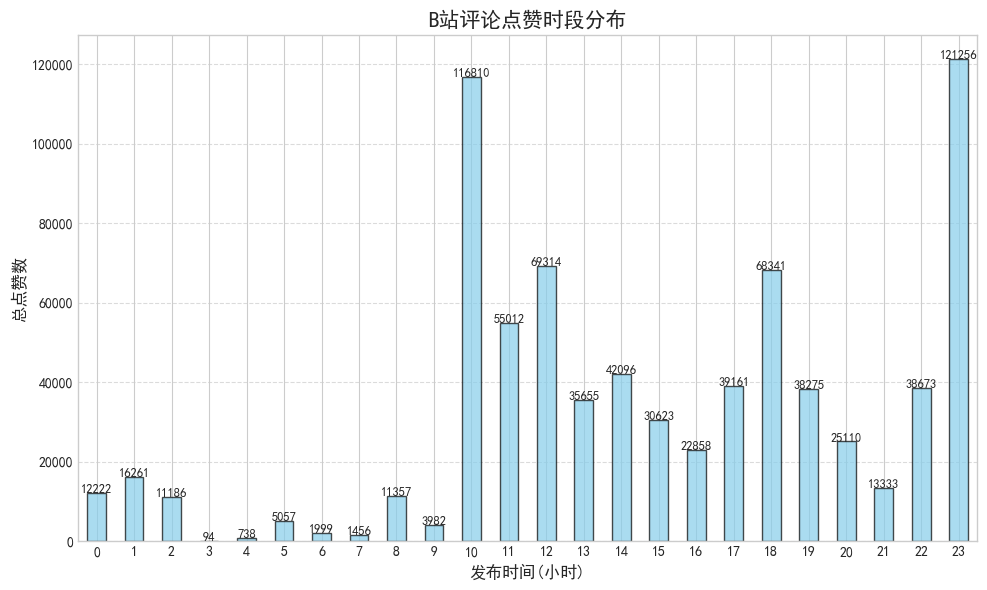

2025-03-23 16:23:48,407 - INFO - 时段点赞分布图绘制完成


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook
import numpy as np
import os
from matplotlib.ticker import MaxNLocator

# 扩展BilibiliDataManager类，添加评论数据加载与分析方法
class CommentAnalyzer:
    """评论数据分析扩展类，配合BilibiliDataManager使用"""
    
    def __init__(self, data_manager):
        """初始化分析器
        
        Args:
            data_manager: BilibiliDataManager实例
        """
        self.data_manager = data_manager
        self.logger = data_manager.logger
        
        # 设置matplotlib中文显示
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        self.logger.info("评论分析器初始化完成")
    
    def load_comments(self):
        """从文件加载评论数据"""
        self.logger.info("开始加载评论数据")
        
        all_comments = []
        file_paths = self.data_manager.get_file_paths()
        
        for file_path in file_paths:
            try:
                self.logger.debug(f"处理文件: {os.path.basename(file_path)}")
                workbook = load_workbook(file_path)
                
                for sheet_name in workbook.sheetnames:
                    sheet = workbook[sheet_name]
                    video_name = sheet.title
                    
                    for row in sheet.iter_rows(min_row=2, values_only=True):
                        if len(row) >= 8 and row[7] and row[6]:  # 确保回复时间和点赞数存在
                            try:
                                reply_time = pd.to_datetime(row[7])
                                likes = int(row[6])
                                level = int(row[5]) if row[5] else 0
                                
                                comment = {
                                    '用户昵称': row[0],
                                    '性别': row[1],
                                    '评论内容': row[2],
                                    '被回复用户': row[3],
                                    '评论层级': row[4],
                                    '用户当前等级': level,
                                    '点赞数量': likes,
                                    '回复时间': reply_time,
                                    '视频ID': sheet_name,
                                    '小时': reply_time.hour,
                                    '日期': reply_time.date(),
                                    '星期': reply_time.dayofweek,
                                    '月份': reply_time.month,
                                    '年份': reply_time.year
                                }
                                all_comments.append(comment)
                            except (ValueError, TypeError) as e:
                                self.logger.warning(f"处理行数据时出错: {e}")
            except Exception as e:
                self.logger.error(f"处理文件 {file_path} 时出错: {e}")
        
        # 更新数据管理器的comments_df
        if all_comments:
            self.data_manager.comments_df = pd.DataFrame(all_comments)
            self.logger.info(f"评论数据加载完成，共 {len(self.data_manager.comments_df)} 条评论")
        else:
            self.logger.warning("未找到任何评论数据")
        
        return self.data_manager.comments_df
    
    def analyze_hourly_likes(self):
        """分析每小时点赞分布并返回结果"""
        self.logger.info("开始分析时段点赞分布")
        
        if self.data_manager.comments_df.empty:
            self.logger.warning("评论数据为空，请先加载数据")
            return None
        
        # 按小时分组并计算点赞数总和
        hourly_likes = self.data_manager.comments_df.groupby('小时')['点赞数量'].sum()
        self.logger.info("时段点赞分析完成")
        
        return hourly_likes
    
    def plot_hourly_likes(self, figsize=(12, 7)):
        """绘制时段点赞分布图"""
        self.logger.info("开始绘制时段点赞分布图")
        
        hourly_likes = self.analyze_hourly_likes()
        if hourly_likes is None:
            return
        
        plt.figure(figsize=figsize)
        ax = hourly_likes.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.7)
        
        # 美化图表
        plt.xlabel('发布时间(小时)', fontsize=12)
        plt.ylabel('总点赞数', fontsize=12)
        plt.title('B站评论点赞时段分布', fontsize=15)
        plt.xticks(rotation=0)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # 在每个柱子上添加数值标签
        for i, v in enumerate(hourly_likes):
            ax.text(i, v + 0.1, f"{int(v)}", ha='center', fontsize=9)
        
        # 确保x轴显示所有24小时
        hours = list(range(24))
        ax.set_xticks(range(len(hours)))
        ax.set_xticklabels(hours)
        
        plt.tight_layout()
        plt.show()
        
        self.logger.info("时段点赞分布图绘制完成")
        return self

# 创建分析器并加载评论数据
analyzer = CommentAnalyzer(bilibili_data)
analyzer.load_comments()

# 绘制时段点赞分布图
analyzer.plot_hourly_likes(figsize=(10, 6))

## 二.用户等级与点赞数的关系

本分析探究B站用户等级与评论获得点赞数之间的相关性，揭示平台用户层级结构对内容影响力的潜在作用。B站拥有完善的用户等级体系，从Lv0到Lv6不等，反映用户的活跃度和平台贡献。通过对比不同等级用户的评论及其获得的点赞数，我们可以理解用户资历与社区认可度之间的关系。

这一分析主要关注以下几个方面：
- **等级分层效应**：高等级用户的评论是否普遍获得更多点赞
- **影响力曲线**：用户等级与平均点赞数之间的函数关系
- **等级阈值**：影响力显著提升的关键等级节点
- **异常模式识别**：低等级但高点赞用户的特征分析

通过这些数据，我们能够揭示：
- B站社区中是否存在明显的"资历权威效应"
- 用户等级作为社会资本如何转化为评论影响力
- 新用户与老用户在内容接受度上的差异
- 平台算法是否对不同等级用户评论有倾向性推荐

这一分析不仅帮助理解B站社区的层级结构特征，也为平台优化推荐机制和新用户融入策略提供数据支持。对内容创作者而言，了解这种关系有助于更好地把握与不同等级粉丝的互动策略，提高社区参与度和评论区活跃度。

2025-03-23 16:23:51,101 - INFO - 用户等级点赞分析器初始化完成
2025-03-23 16:23:51,101 - INFO - 开始绘制用户等级点赞散点图
2025-03-23 16:23:51,102 - INFO - 开始分析用户等级与点赞数关系
2025-03-23 16:23:51,105 - INFO - 用户等级点赞关系分析完成，共处理 870 条数据


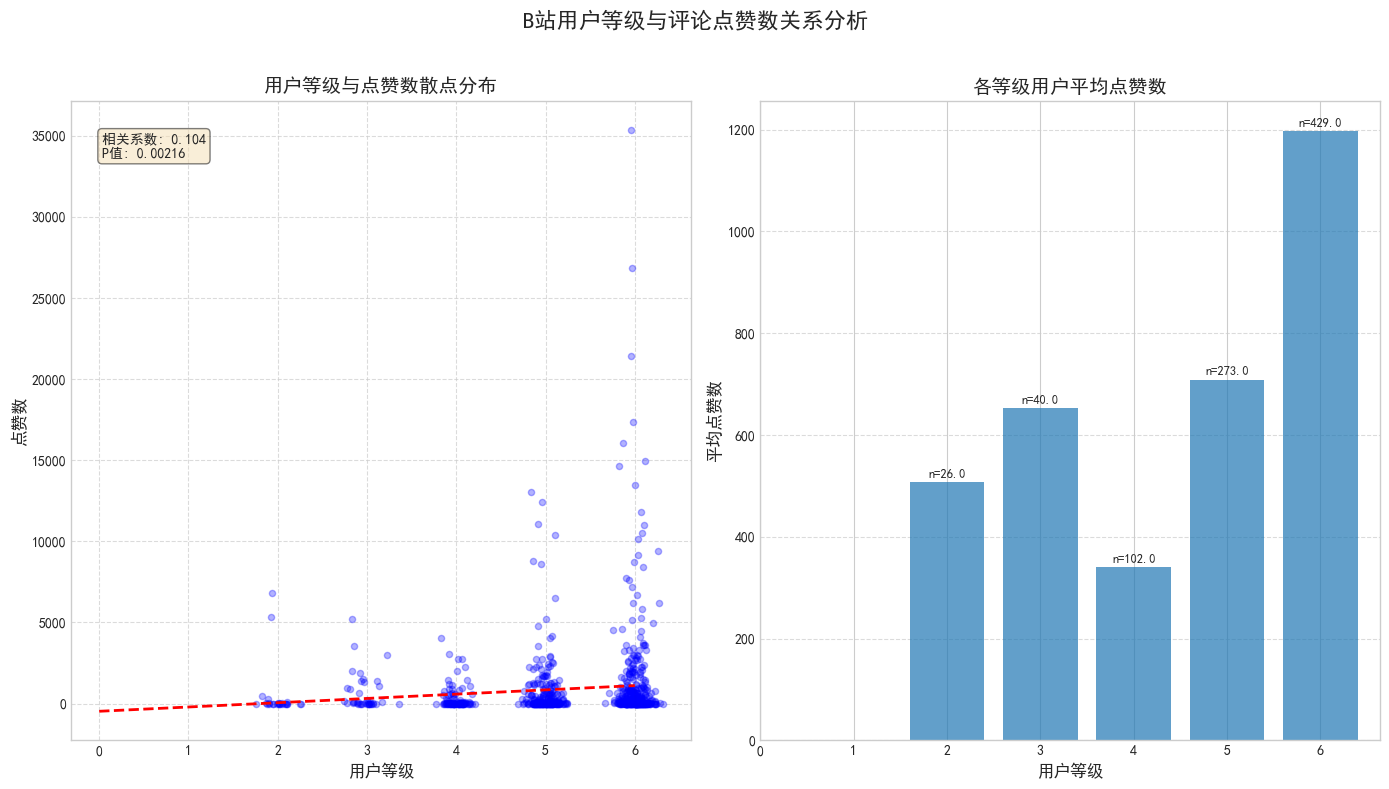

2025-03-23 16:23:51,263 - INFO - 用户等级点赞散点图绘制完成


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import stats

class UserLevelAnalyzer:
    """用户等级点赞关系分析器，配合BilibiliDataManager使用"""
    
    def __init__(self, data_manager):
        """初始化分析器
        
        Args:
            data_manager: BilibiliDataManager实例
        """
        self.data_manager = data_manager
        self.logger = data_manager.logger
        
        # 设置matplotlib中文显示
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        self.logger.info("用户等级点赞分析器初始化完成")
    
    def analyze_level_and_likes(self):
        """分析用户等级与点赞数关系"""
        if self.data_manager.comments_df.empty:
            self.logger.warning("评论数据为空，请先加载数据")
            return None
            
        self.logger.info("开始分析用户等级与点赞数关系")
        
        # 提取数据
        level_likes_df = self.data_manager.comments_df[['用户当前等级', '点赞数量']].copy()
        level_likes_df.columns = ['Level', 'Likes']
        
        # 移除异常值（可选）
        # level_likes_df = level_likes_df[level_likes_df['Likes'] < level_likes_df['Likes'].quantile(0.99)]
        
        # 按用户等级计算统计值
        level_stats = level_likes_df.groupby('Level')['Likes'].agg([
            ('平均点赞数', 'mean'), 
            ('中位点赞数', 'median'),
            ('最大点赞数', 'max'),
            ('样本数', 'size')
        ]).reset_index()
        
        self.logger.info(f"用户等级点赞关系分析完成，共处理 {len(level_likes_df)} 条数据")
        
        return {
            'raw_data': level_likes_df,
            'level_stats': level_stats
        }
    
    def plot_level_likes_scatter(self, figsize=(12, 8)):
        """绘制用户等级点赞散点图"""
        self.logger.info("开始绘制用户等级点赞散点图")
        
        analysis_result = self.analyze_level_and_likes()
        if not analysis_result:
            return
            
        df = analysis_result['raw_data']
        stats_df = analysis_result['level_stats']
        
        # 创建图形
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # 散点图 - 添加随机抖动避免重叠
        jitter = np.random.normal(0, 0.1, size=len(df))
        ax1.scatter(df['Level'] + jitter, df['Likes'], alpha=0.3, color='blue', s=20)
        
        # 添加趋势线
        try:
            z = np.polyfit(df['Level'], df['Likes'], 1)
            p = np.poly1d(z)
            ax1.plot(range(0, 7), p(range(0, 7)), "r--", linewidth=2)
            
            # 计算相关系数
            corr, p_value = stats.pearsonr(df['Level'], df['Likes'])
            ax1.text(0.05, 0.95, f"相关系数: {corr:.3f}\nP值: {p_value:.5f}", 
                    transform=ax1.transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        except:
            self.logger.warning("计算趋势线时出错，可能是数据不足")
        
        # 设置图表属性
        ax1.set_xlabel('用户等级', fontsize=12)
        ax1.set_ylabel('点赞数', fontsize=12)
        ax1.set_title('用户等级与点赞数散点分布', fontsize=14)
        ax1.grid(True, linestyle='--', alpha=0.7)
        ax1.set_xticks(range(0, 7))
        
        # 绘制等级统计条形图
        bars = ax2.bar(stats_df['Level'], stats_df['平均点赞数'], alpha=0.7)
        
        # 在条形上添加样本数量标签
        for i, bar in enumerate(bars):
            height = bar.get_height()
            sample_size = stats_df.iloc[i]['样本数']
            ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
                    f'n={sample_size}', ha='center', va='bottom', fontsize=9)
        
        ax2.set_xlabel('用户等级', fontsize=12)
        ax2.set_ylabel('平均点赞数', fontsize=12)
        ax2.set_title('各等级用户平均点赞数', fontsize=14)
        ax2.grid(axis='y', linestyle='--', alpha=0.7)
        ax2.set_xticks(range(0, 7))
        
        # 添加总标题
        plt.suptitle('B站用户等级与评论点赞数关系分析', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        
        self.logger.info("用户等级点赞散点图绘制完成")
        return self

# 创建用户等级分析器并绘制图表
level_analyzer = UserLevelAnalyzer(bilibili_data)
level_analyzer.plot_level_likes_scatter(figsize=(14, 8))

## 三.点赞数与二级评论数的关系+热度曲线
### 1.生成一级评论点赞数-二级评论数分布图

这个散点图揭示了一级评论获得的点赞数与其引发的二级评论数量之间的相关关系。通过对所有视频评论数据的分析，我们可以观察到热门评论的传播机制和用户互动行为模式。

图表的主要观察点包括：
- 高点赞评论是否必然引发更多的二级回复
- 二级评论数与点赞数之间是否存在明显的线性或非线性关系
- 异常点的分布，即那些点赞数不高但二级评论丰富的情况，或反之

这一分析有助于理解B站评论区的互动链传播规律，揭示哪类评论更容易引发讨论，为社区运营提供数据支持。

2025-03-23 16:23:54,180 - INFO - 评论关系分析器初始化完成
2025-03-23 16:23:54,180 - INFO - 开始绘制点赞-二级评论关系图
2025-03-23 16:23:54,181 - INFO - 开始分析一级评论点赞数与二级评论数量关系
2025-03-23 16:23:54,182 - INFO - 共找到 492 条一级评论和 378 条二级评论
2025-03-23 16:23:54,187 - INFO - 完成数据合并，最终获得 492 条有效数据


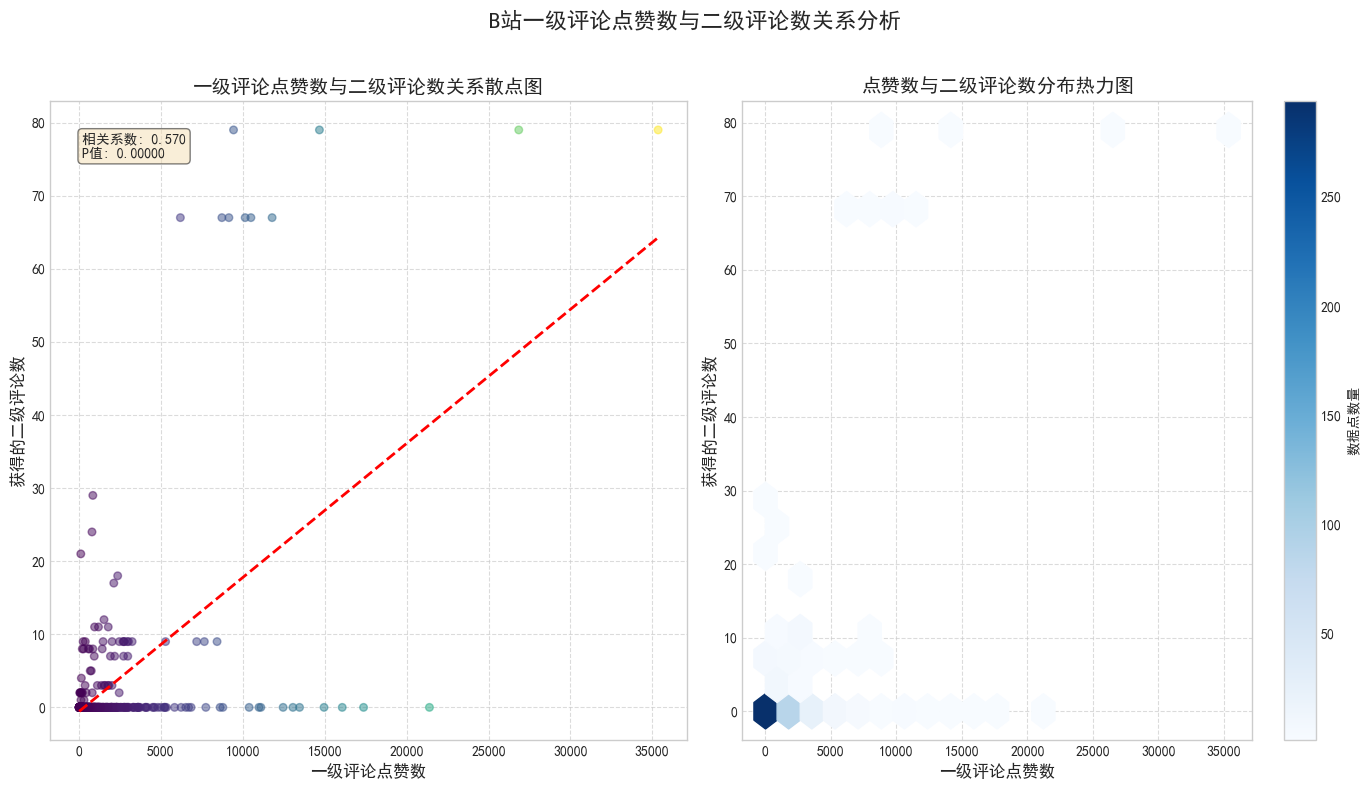

2025-03-23 16:23:54,406 - INFO - 点赞-二级评论关系图绘制完成


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

class CommentRelationAnalyzer:
    """B站评论关系分析器，分析一级评论点赞数与二级评论数量的关系"""
    
    def __init__(self, data_manager):
        """初始化分析器
        
        Args:
            data_manager: BilibiliDataManager实例
        """
        self.data_manager = data_manager
        self.logger = data_manager.logger
        
        # 设置matplotlib中文显示
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        self.logger.info("评论关系分析器初始化完成")
    
    def analyze_likes_replies_relation(self):
        """分析一级评论点赞数与获得的二级评论数量的关系"""
        if self.data_manager.comments_df.empty:
            self.logger.warning("评论数据为空，请先加载数据")
            return None
            
        self.logger.info("开始分析一级评论点赞数与二级评论数量关系")
        
        # 过滤出一级评论和二级评论
        df = self.data_manager.comments_df
        df_primary = df[df['评论层级'] == '一级评论']
        df_secondary = df[df['评论层级'] == '二级评论']
        
        self.logger.info(f"共找到 {len(df_primary)} 条一级评论和 {len(df_secondary)} 条二级评论")
        
        # 计算每个一级评论获得的二级评论数量
        secondary_counts = df_secondary.groupby('被回复用户').size().reset_index(name='二级评论数')
        
        # 合并一级评论的点赞数与其获得的二级评论数
        merged_df = pd.merge(
            df_primary[['用户昵称', '点赞数量']], 
            secondary_counts,
            left_on='用户昵称', 
            right_on='被回复用户', 
            how='left'
        )
        
        # 填充没有二级评论的情况为0
        merged_df['二级评论数'] = merged_df['二级评论数'].fillna(0)
        
        self.logger.info(f"完成数据合并，最终获得 {len(merged_df)} 条有效数据")
        
        return merged_df
    
    def plot_likes_replies_relation(self, figsize=(14, 8)):
        """绘制一级评论点赞数与二级评论数关系图"""
        self.logger.info("开始绘制点赞-二级评论关系图")
        
        data = self.analyze_likes_replies_relation()
        if data is None:
            return
        
        # 创建图形
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # 左侧: 散点图
        scatter = ax1.scatter(
            data['点赞数量'], 
            data['二级评论数'],
            alpha=0.5,
            c=data['点赞数量'], 
            cmap='viridis',
            s=30
        )
        
        # 添加趋势线
        try:
            z = np.polyfit(data['点赞数量'], data['二级评论数'], 1)
            p = np.poly1d(z)
            x_range = np.linspace(data['点赞数量'].min(), data['点赞数量'].max(), 100)
            ax1.plot(x_range, p(x_range), "r--", linewidth=2)
            
            # 计算相关系数
            corr, p_value = stats.pearsonr(data['点赞数量'], data['二级评论数'])
            ax1.text(
                0.05, 0.95, 
                f"相关系数: {corr:.3f}\nP值: {p_value:.5f}", 
                transform=ax1.transAxes, 
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            )
        except Exception as e:
            self.logger.warning(f"计算趋势线时出错: {e}")
        
        # 坐标轴设置
        ax1.set_xlabel('一级评论点赞数', fontsize=12)
        ax1.set_ylabel('获得的二级评论数', fontsize=12)
        ax1.set_title('一级评论点赞数与二级评论数关系散点图', fontsize=14)
        ax1.grid(True, linestyle='--', alpha=0.7)
        
        # 右侧: 热力分布图 (使用hexbin)
        hb = ax2.hexbin(
            data['点赞数量'], 
            data['二级评论数'], 
            gridsize=20, 
            cmap='Blues',
            mincnt=1
        )
        fig.colorbar(hb, ax=ax2, label='数据点数量')
        
        # 热力图设置
        ax2.set_xlabel('一级评论点赞数', fontsize=12)
        ax2.set_ylabel('获得的二级评论数', fontsize=12)
        ax2.set_title('点赞数与二级评论数分布热力图', fontsize=14)
        ax2.grid(True, linestyle='--', alpha=0.7)
        
        # 创建总标题
        plt.suptitle('B站一级评论点赞数与二级评论数关系分析', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        
        self.logger.info("点赞-二级评论关系图绘制完成")
        return self

# 创建评论关系分析器并绘制图表
relation_analyzer = CommentRelationAnalyzer(bilibili_data)
relation_analyzer.plot_likes_replies_relation()

### 2.生成交互评论网络图

交互评论网络图是一种复杂网络可视化方法，通过节点和连线直观展示B站用户评论之间的互动关系。在这个网络图中，每个节点代表一个用户，连线则表示用户之间的回复关系，连线粗细反映互动强度，节点大小对应用户的活跃度或影响力。

通过分析这一网络图，我们可以发现：
- 评论区的意见领袖（关键节点），即那些引发大量讨论的核心用户
- 互动社群的形成模式，表现为网络中的聚类现象
- 信息流动路径，揭示内容和观点如何在用户间传播
- 讨论主题的分化与融合，体现为网络的分支结构和连接桥梁

这种网络分析对于理解B站社区结构和用户互动模式具有独特价值。它不仅能识别出最具影响力的社区成员，还能揭示评论区的隐藏层次结构和信息扩散机制。对内容创作者而言，这一分析有助于识别潜在的意见领袖和活跃粉丝，为社区运营和互动策略提供数据支持。

本图采用Force-directed算法布局，通过物理模拟使网络结构更加直观，相关度高的节点会自然聚集在一起，形成视觉上的社群划分。

In [ ]:
import os
from openpyxl import load_workbook
from pyvis.network import Network
import webbrowser
import matplotlib.pyplot as plt
import pandas as pd
import random
from IPython.display import display, HTML
import time

class NetworkVisualizer:
    """B站评论网络可视化工具，生成互动关系交互图"""
    
    def __init__(self, data_manager):
        """初始化网络可视化器
        
        Args:
            data_manager: BilibiliDataManager实例
        """
        self.data_manager = data_manager
        self.logger = data_manager.logger
        
        # 定义根节点名称
        self.ROOT_NODE = "Bilibili"
        # 节点数量限制参数
        self.MAX_VIDEOS = 8                # 最大视频节点数
        self.MAX_PRIMARY_PER_VIDEO = 15    # 每个视频最多显示的一级评论数
        self.MAX_SECONDARY_PER_USER = 5    # 每个用户最多显示的二级评论数
        self.SHOW_PROGRESS = True          # 是否显示加载进度
        
        self.logger.info("网络可视化器初始化完成")
    
    def generate_interactive_network(self, output_html="interactive_network.html", 
                                    max_videos=None, max_primary=None, max_secondary=None):
        """生成交互式评论网络图
        
        Args:
            output_html: 输出的HTML文件名
            max_videos: 最大视频数量，默认为8
            max_primary: 每个视频最大一级评论数，默认为15
            max_secondary: 每个用户最大二级评论数，默认为5
        """
        # 更新参数(如果提供)
        if max_videos is not None:
            self.MAX_VIDEOS = max_videos
        if max_primary is not None:
            self.MAX_PRIMARY_PER_VIDEO = max_primary
        if max_secondary is not None:
            self.MAX_SECONDARY_PER_USER = max_secondary
            
        if self.SHOW_PROGRESS:
            progress_html = HTML("<div id='progress'>准备生成网络图...</div>")
            display(progress_html)
        
        self.logger.info("开始生成交互式评论网络图，已限制节点数量")
        
        # 获取文件列表
        file_paths = self.data_manager.get_file_paths()
        
        if not file_paths:
            self.logger.warning("未找到数据文件，无法生成网络图")
            if self.SHOW_PROGRESS:
                display(HTML("<div style='color:red'>错误：未找到数据文件</div>"))
            return
        
        # 如果文件太多，随机选择一部分
        if len(file_paths) > self.MAX_VIDEOS:
            self.logger.info(f"文件数量({len(file_paths)})超过限制({self.MAX_VIDEOS})，将随机采样")
            file_paths = random.sample(file_paths, self.MAX_VIDEOS)
            
        # 创建 Pyvis 网络图 - 使用更轻量的物理引擎
        net = Network(height="750px", width="100%", directed=True, bgcolor="#222222", font_color="white")
        
        # 添加根节点
        net.add_node(self.ROOT_NODE, label=self.ROOT_NODE, color="#ff6699", shape="star", size=40)
        
        file_count = 0
        comment_count = 0
        
        # 更新进度
        if self.SHOW_PROGRESS:
            display(HTML(f"<div id='progress'>加载数据文件 (0/{len(file_paths)})...</div>"))
        
        # 遍历所有文件并提取数据
        for i, file_path in enumerate(file_paths):
            try:
                # 更新进度
                if self.SHOW_PROGRESS:
                    display(HTML(f"<div id='progress'>加载数据文件 ({i+1}/{len(file_paths)})...</div>"))
                
                # 从文件名获取信息
                file_name = os.path.basename(file_path)
                table_index = file_name.split('_')[-1].split('.')[0] if '_' in file_name else '0'
                table_node = f"Table {table_index}"
                
                self.logger.debug(f"处理数据文件: {file_name}")
                
                # 添加表格节点
                net.add_node(table_node, label=table_node, color="orange", shape="circle", size=25)
                net.add_edge(self.ROOT_NODE, table_node)
                
                # 使用已加载的数据或从文件加载
                if not hasattr(self.data_manager, 'comments_df') or self.data_manager.comments_df.empty:
                    # 从文件加载
                    self._add_nodes_from_file(net, file_path, table_node)
                else:
                    # 使用已加载的数据框
                    self._add_nodes_from_dataframe(net, table_node)
                
                file_count += 1
                
            except Exception as e:
                self.logger.error(f"处理文件 {file_path} 时出错: {e}")
        
        # 设置优化后的物理引擎参数 - 降低计算复杂度
        net.set_options("""
        var options = {
          "nodes": {
            "font": {
              "size": 12,
              "face": "Arial"
            }
          },
          "physics": {
            "forceAtlas2Based": {
              "gravitationalConstant": -50,
              "centralGravity": 0.01,
              "springLength": 100,
              "springConstant": 0.08
            },
            "solver": "forceAtlas2Based",
            "stabilization": {
              "enabled": true,
              "iterations": 50,
              "updateInterval": 25
            },
            "maxVelocity": 50,
            "minVelocity": 0.75
          },
          "interaction": {
            "tooltipDelay": 200,
            "hideEdgesOnDrag": true,
            "hideNodesOnDrag": false
          }
        }
        """)
        
        # 更新进度
        if self.SHOW_PROGRESS:
            display(HTML(f"<div id='progress'>正在保存网络图...</div>"))
        
        # 添加使用说明和注释
        disclaimer = """
        <div style="background-color:#333; color:#fff; padding:10px; margin-top:20px; font-family:Arial;">
        <h3>📊 B站评论网络可视化图</h3>
        <p>此图展示了B站热门评论的互动关系网络：</p>
        <ul>
            <li>⭐ <b>中心星形节点</b>：代表整个B站平台</li>
            <li>🟠 <b>橙色节点</b>：代表数据集</li>
            <li>🔵 <b>蓝色节点</b>：代表视频</li>
            <li>🟢 <b>绿色节点</b>：代表一级评论用户</li>
            <li>🔹 <b>浅蓝色节点</b>：代表二级评论用户</li>
        </ul>
        <p>使用说明：</p>
        <ul>
            <li>⚙️ <b>缩放</b>：使用鼠标滚轮放大/缩小</li>
            <li>👆 <b>拖动</b>：按住鼠标左键拖动画布</li>
            <li>🔍 <b>查看详情</b>：将鼠标悬停在节点上显示评论内容</li>
            <li>📌 <b>固定节点</b>：双击节点可固定/取消固定位置</li>
        </ul>
        <p style="font-size:0.8em; color:#aaa;">注：为提高加载速度，仅显示了部分评论数据</p>
        </div>
        """
        
        # 保存为HTML文件
        html_content = net.generate_html()
        # 在</body>标签前插入使用说明
        html_content = html_content.replace("</body>", f"{disclaimer}</body>")
        
        with open(output_html, "w", encoding="utf-8") as f:
            f.write(html_content)
            
        self.logger.info(f"交互式网络图已保存为 {output_html}, 包含 {file_count} 个视频数据")
        
        # 更新完成状态
        if self.SHOW_PROGRESS:
            display(HTML(f"<div id='progress' style='color:green'>✅ 网络图生成完成！</div>"))
        
        return self
    
    def _add_nodes_from_dataframe(self, net, table_node):
        """从已加载的DataFrame添加节点（带限制）"""
        # 按视频ID分组处理评论
        grouped = self.data_manager.comments_df.groupby('视频ID')
        
        # 如果视频太多，随机选择一部分
        video_ids = list(grouped.groups.keys())
        if len(video_ids) > self.MAX_VIDEOS:
            video_ids = random.sample(video_ids, self.MAX_VIDEOS)
        
        for video_id in video_ids:
            video_comments = grouped.get_group(video_id)
            
            # 获取视频名称
            video_name = video_id  # 默认使用ID
            if '视频名称' in video_comments.columns:
                video_name = video_comments['视频名称'].iloc[0]
            
            # 如果视频标题过长，省略显示
            display_name = video_name if len(str(video_name)) <= 15 else video_name[:12] + "..."
            
            # 添加视频节点
            net.add_node(video_name, label=display_name, title=video_name, color="skyblue", shape="circle", size=20)
            net.add_edge(table_node, video_name)
            
            # 处理一级评论 - 按点赞数排序并限制数量
            primary_comments = video_comments[video_comments['评论层级'] == '一级评论']
            if '点赞数' in primary_comments.columns:
                primary_comments = primary_comments.sort_values('点赞数', ascending=False)
            
            # 限制一级评论数量
            primary_comments = primary_comments.head(self.MAX_PRIMARY_PER_VIDEO)
            
            for _, comment in primary_comments.iterrows():
                user_name = comment['用户昵称']
                comment_content = comment['评论内容']
                
                # 如果昵称过长，缩短显示
                display_user = user_name if len(str(user_name)) <= 10 else str(user_name)[:8] + ".."
                
                # 处理显示内容
                display_content = str(comment_content)
                if len(display_content) > 50:
                    display_content = display_content[:47] + "..."
                
                # 添加一级评论用户节点
                net.add_node(
                    user_name,
                    label=display_user,
                    title=display_content,  # 鼠标悬停显示评论内容
                    color="lightgreen",
                    shape="dot",
                    size=15
                )
                net.add_edge(video_name, user_name)
            
            # 为每个一级评论用户添加有限数量的二级评论
            for _, primary_comment in primary_comments.iterrows():
                primary_user = primary_comment['用户昵称']
                
                # 获取对该用户的二级评论
                secondary_comments = video_comments[
                    (video_comments['评论层级'] == '二级评论') & 
                    (video_comments['被回复用户'] == primary_user)
                ]
                
                # 限制每个用户的二级评论数量
                if len(secondary_comments) > self.MAX_SECONDARY_PER_USER:
                    secondary_comments = secondary_comments.sample(self.MAX_SECONDARY_PER_USER)
                
                for _, comment in secondary_comments.iterrows():
                    user_name = comment['用户昵称']
                    comment_content = comment['评论内容']
                    
                    # 如果昵称过长，缩短显示
                    display_user = user_name if len(str(user_name)) <= 8 else str(user_name)[:6] + ".."
                    
                    # 处理显示内容
                    display_content = str(comment_content)
                    if len(display_content) > 50:
                        display_content = display_content[:47] + "..."
                    
                    # 添加二级评论用户节点
                    net.add_node(
                        user_name,
                        label=display_user,
                        title=display_content,
                        color="lightblue", 
                        shape="dot",
                        size=10
                    )
                    net.add_edge(primary_user, user_name)
    
    def _add_nodes_from_file(self, net, file_path, table_node):
        """从Excel文件添加节点（带限制）"""
        try:
            workbook = load_workbook(file_path, data_only=True, read_only=True)  # 使用read_only模式提高性能
            
            # 如果sheet太多，随机选择一部分
            sheet_names = workbook.sheetnames
            if len(sheet_names) > self.MAX_VIDEOS:
                sheet_names = random.sample(sheet_names, self.MAX_VIDEOS)
            
            # 遍历每个表格的Sheet
            for sheet_name in sheet_names:
                sheet = workbook[sheet_name]
                
                # 获取视频名称
                video_name = None
                for row in sheet.iter_rows(min_row=1, max_row=1, min_col=9, max_col=9, values_only=True):
                    video_name = row[0]
                    break
                
                if not video_name:
                    video_name = sheet_name
                
                # 如果视频标题过长，省略显示
                display_name = video_name if len(str(video_name)) <= 15 else str(video_name)[:12] + "..."
                
                # 添加视频名称节点
                net.add_node(video_name, label=display_name, title=str(video_name), color="skyblue", shape="circle", size=20)
                net.add_edge(table_node, video_name)
                
                # 收集评论数据以便排序和筛选
                primary_comments = []
                secondary_comments = {}
                
                # 先遍历并收集数据
                row_count = 0
                for row in sheet.iter_rows(min_row=2, values_only=True):
                    row_count += 1
                    if len(row) < 5 or row_count > 500:  # 限制最大行数，避免过多解析
                        continue
                        
                    user_name = row[0]  # 评论用户
                    likes = row[1] if len(row) > 1 else 0  # 点赞数
                    comment_content = row[2]  # 评论内容
                    comment_level = row[4]  # 评论层级
                    replied_user = row[3]  # 被评论用户
                    
                    if comment_level == "一级评论":
                        primary_comments.append((user_name, likes, comment_content))
                    elif comment_level == "二级评论" and replied_user:
                        if replied_user not in secondary_comments:
                            secondary_comments[replied_user] = []
                        secondary_comments[replied_user].append((user_name, comment_content))
                
                # 对一级评论按点赞数排序并限制数量
                primary_comments.sort(key=lambda x: x[1] if x[1] is not None else 0, reverse=True)
                primary_comments = primary_comments[:self.MAX_PRIMARY_PER_VIDEO]
                
                # 添加一级评论节点
                for user_name, _, comment_content in primary_comments:
                    # 如果昵称过长，缩短显示
                    display_user = user_name if len(str(user_name)) <= 10 else str(user_name)[:8] + ".."
                    
                    # 处理显示内容
                    display_content = str(comment_content) if comment_content else ""
                    if len(display_content) > 50:
                        display_content = display_content[:47] + "..."
                    
                    # 添加一级评论用户节点
                    net.add_node(
                        user_name,
                        label=display_user,
                        title=display_content,  # 鼠标悬停显示评论内容
                        color="lightgreen",
                        shape="dot",
                        size=15
                    )
                    net.add_edge(video_name, user_name)
                    
                    # 添加该用户的二级评论（有限数量）
                    if user_name in secondary_comments:
                        replies = secondary_comments[user_name]
                        # 如果回复太多，随机选择一部分
                        if len(replies) > self.MAX_SECONDARY_PER_USER:
                            replies = random.sample(replies, self.MAX_SECONDARY_PER_USER)
                            
                        for reply_user, reply_content in replies:
                            # 如果昵称过长，缩短显示
                            display_reply_user = reply_user if len(str(reply_user)) <= 8 else str(reply_user)[:6] + ".."
                            
                            # 处理显示内容
                            display_reply = str(reply_content) if reply_content else ""
                            if len(display_reply) > 50:
                                display_reply = display_reply[:47] + "..."
                                
                            # 添加二级评论用户节点
                            net.add_node(
                                reply_user,
                                label=display_reply_user,
                                title=display_reply,
                                color="lightblue", 
                                shape="dot",
                                size=10
                            )
                            net.add_edge(user_name, reply_user)
                
        except Exception as e:
            self.logger.error(f"解析文件 {file_path} 时出错: {e}")


# 创建可视化器并生成交互式网络图
visualizer = NetworkVisualizer(bilibili_data)
# 可以通过参数调整不同的节点数量限制
visualizer.generate_interactive_network(
    output_html="interactive_network.html",
    max_videos=8,            # 最多显示8个视频
    max_primary=15,          # 每个视频最多显示15条一级评论
    max_secondary=5          # 每个用户最多显示5条二级评论
)

2025-03-23 17:05:17,105 - INFO - 网络可视化器初始化完成


2025-03-23 17:05:17,107 - INFO - 开始生成交互式评论网络图，已限制节点数量
2025-03-23 17:05:17,107 - INFO - 访问属性: 文件路径, 第 6 次访问
2025-03-23 17:05:17,108 - INFO - 文件数量(9)超过限制(8)，将随机采样


2025-03-23 17:05:17,414 - INFO - 交互式网络图已保存为 interactive_network.html, 包含 8 个视频数据


In [ ]:
import ipywidgets as widgets
from IPython.display import display

# 创建用于控制节点数量的滑块
max_videos_slider = widgets.IntSlider(
    value=8,
    min=1,
    max=20,
    step=1,
    description='最大视频数:',
    style={'description_width': '150px'},
    continuous_update=False
)

max_primary_slider = widgets.IntSlider(
    value=15,
    min=1,
    max=50,
    step=1,
    description='每视频一级评论:',
    style={'description_width': '150px'},
    continuous_update=False
)

max_secondary_slider = widgets.IntSlider(
    value=5,
    min=1,
    max=20,
    step=1,
    description='每用户二级评论:',
    style={'description_width': '150px'},
    continuous_update=False
)

# 创建一个按钮以触发网络图更新
update_button = widgets.Button(
    description='更新网络图',
    button_style='success',
    tooltip='点击更新网络图'
)

# 输出区域
output_area = widgets.Output()

# 定义按钮点击事件，将使用当前滑块参数调用 visualizer.generate_interactive_network
def update_network(b):
    with output_area:
        output_area.clear_output()
        visualizer.generate_interactive_network(
            output_html="interactive_network.html",
            max_videos=max_videos_slider.value,
            max_primary=max_primary_slider.value,
            max_secondary=max_secondary_slider.value
        )
        # 自动打开浏览器
    webbrowser.open("interactive_network.html")

update_button.on_click(update_network)

# 显示所有控件
display(widgets.VBox([
    max_videos_slider,
    max_primary_slider,
    max_secondary_slider,
    update_button,
    output_area
]))

## 四.等级-评论点赞-二级回复数三维图

这一三维可视化图表将B站用户等级、评论点赞数和二级回复数三个关键指标整合在同一空间中，揭示它们之间复杂的交互关系。通过三维散点图和曲面拟合，我们能够直观观察到这三个变量之间的多维相关性，发掘传统二维分析难以捕捉的模式。

这一创新性分析主要探究：
- **交互效应**：用户等级如何同时调节点赞数与二级回复数的关系
- **聚类现象**：不同等级用户在互动指标空间中的分布集群
- **非线性关系**：三个变量之间可能存在的复杂曲面关系
- **影响力立体模型**：构建预测用户评论影响力的多维度框架

通过分析这一三维图表，我们可以揭示：
- 特定等级区间用户在获取点赞与引发讨论之间的平衡策略
- "意见领袖"用户的立体特征画像，即同时获得高点赞和高回复量的用户特点
- 用户等级提升对评论影响力的边际效应，判断等级提升的实际价值
- 评论互动的最优组合区域，帮助理解高效互动的多维条件

这种多维度分析突破了传统二元关系研究的局限，为理解B站复杂的社区互动机制提供了更全面的视角。通过识别三个变量的协同效应，我们能够构建更精确的用户影响力预测模型，为内容创作者和平台运营提供更具战略性的数据支持。

2025-03-23 16:24:32,926 - INFO - 多维数据分析器初始化完成
2025-03-23 16:24:32,926 - INFO - 开始绘制用户等级-点赞数-二级回复数三维图
2025-03-23 16:24:32,927 - INFO - 开始分析用户等级-点赞数-二级回复数三维关系
2025-03-23 16:24:32,929 - INFO - 找到 492 条一级评论和 378 条二级评论
2025-03-23 16:24:32,933 - INFO - 三维关系数据准备完成，共 492 条有效数据


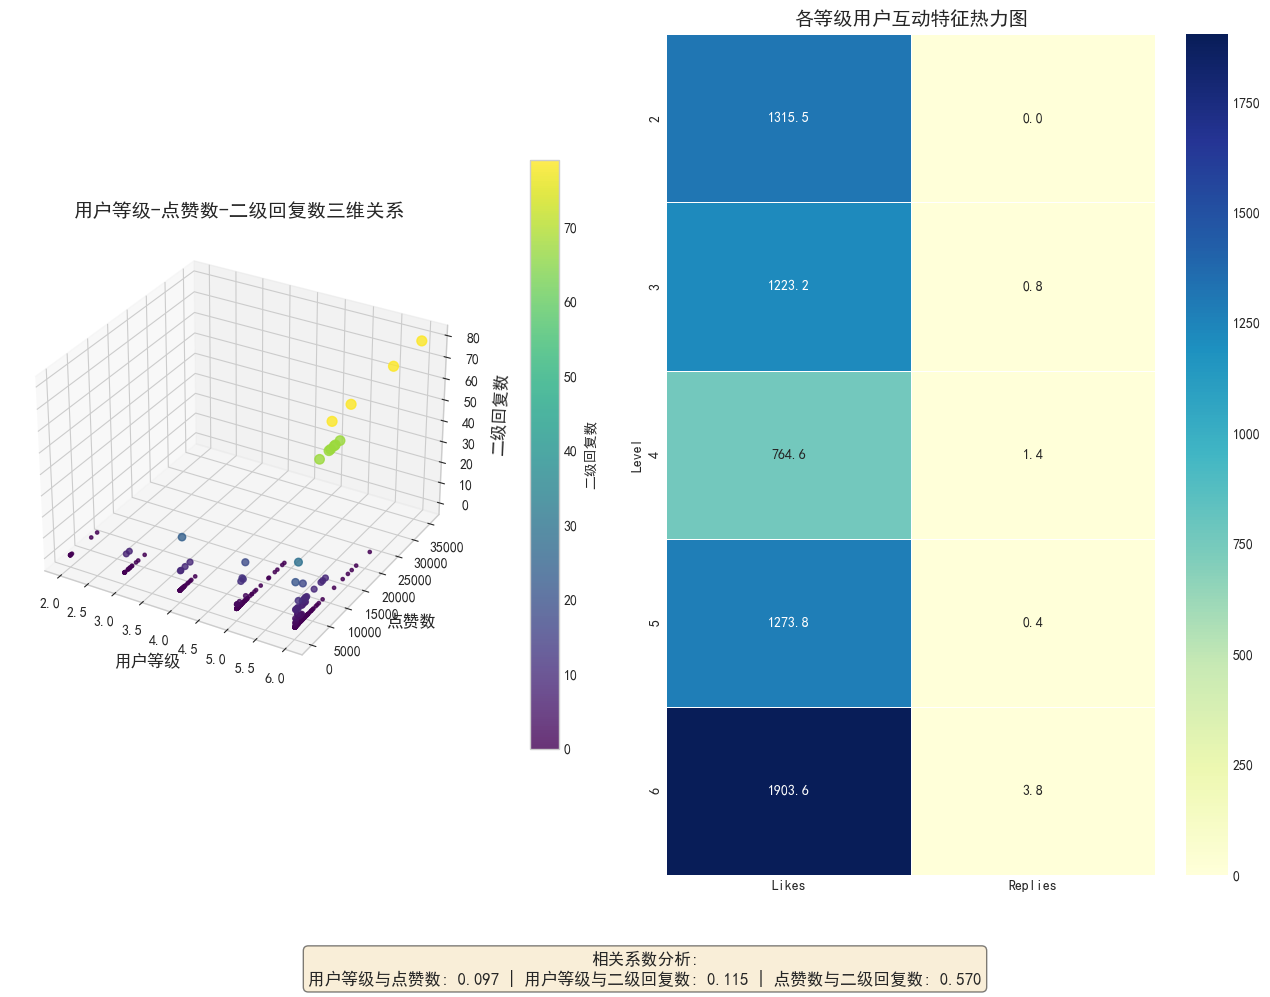

2025-03-23 16:24:33,367 - INFO - 三维关系图绘制完成


In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import numpy as np
import seaborn as sns

class MultiDimensionalAnalyzer:
    """B站多维数据分析器，分析用户等级、点赞数与二级回复数的三维关系"""
    
    def __init__(self, data_manager):
        """初始化多维分析器
        
        Args:
            data_manager: BilibiliDataManager实例
        """
        self.data_manager = data_manager
        self.logger = data_manager.logger
        
        # 设置matplotlib中文显示
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        self.logger.info("多维数据分析器初始化完成")
    
    def analyze_level_likes_replies(self):
        """分析用户等级、点赞数与二级回复数的关系数据"""
        if self.data_manager.comments_df.empty:
            self.logger.warning("评论数据为空，请先加载数据")
            return None
        
        self.logger.info("开始分析用户等级-点赞数-二级回复数三维关系")
        
        # 过滤出一级评论和二级评论
        df = self.data_manager.comments_df
        df_primary = df[df['评论层级'] == '一级评论'].copy()
        df_secondary = df[df['评论层级'] == '二级评论'].copy()
        
        self.logger.info(f"找到 {len(df_primary)} 条一级评论和 {len(df_secondary)} 条二级评论")
        
        # 统计每个用户的二级回复数量
        reply_counts = df_secondary.groupby('被回复用户').size().reset_index(name='二级评论数')
        
        # 合并一级评论数据与二级回复计数
        result_df = pd.merge(
            df_primary[['用户昵称', '用户当前等级', '点赞数量']], 
            reply_counts,
            left_on='用户昵称', 
            right_on='被回复用户', 
            how='left'
        )
        
        # 填充没有二级回复的用户为0
        result_df['二级评论数'] = result_df['二级评论数'].fillna(0)
        
        # 重命名列以保持一致性
        final_df = result_df[['用户当前等级', '点赞数量', '二级评论数']].rename(
            columns={'用户当前等级': 'Level', '点赞数量': 'Likes', '二级评论数': 'Replies'}
        )
        
        self.logger.info(f"三维关系数据准备完成，共 {len(final_df)} 条有效数据")
        return final_df
    
    def plot_3d_relationship(self, figsize=(13, 10)):
        """绘制三维关系图表"""
        self.logger.info("开始绘制用户等级-点赞数-二级回复数三维图")
        
        df = self.analyze_level_likes_replies()
        if df is None:
            return
        
        # 创建一个包含多个子图的画布
        fig = plt.figure(figsize=figsize)
        
        # 添加3D散点图
        ax1 = fig.add_subplot(121, projection='3d')
        sc = ax1.scatter(
            df['Level'], 
            df['Likes'], 
            df['Replies'],
            c=df['Replies'], 
            cmap='viridis', 
            s=50*np.sqrt(df['Replies']+1)/np.sqrt(df['Replies'].max()+1), 
            alpha=0.8
        )
        
        # 设置坐标轴
        ax1.set_xlabel('用户等级', fontsize=12)
        ax1.set_ylabel('点赞数', fontsize=12)
        ax1.set_zlabel('二级回复数', fontsize=12)
        ax1.set_title('用户等级-点赞数-二级回复数三维关系', fontsize=14)
        
        # 添加颜色条
        cbar = plt.colorbar(sc, ax=ax1, pad=0.1, shrink=0.7)
        cbar.set_label('二级回复数', fontsize=10)
        
        # 添加热力图 - 用户等级与平均点赞/回复关系
        ax2 = fig.add_subplot(122)
        pivot_df = df.pivot_table(
            index='Level',
            values=['Likes', 'Replies'],
            aggfunc={'Likes': 'mean', 'Replies': 'mean'}
        ).reset_index()
        
        # 创建级别与互动的比例表
        heatmap_data = pivot_df.set_index('Level')
        sns.heatmap(
            heatmap_data, 
            annot=True, 
            cmap='YlGnBu', 
            fmt='.1f', 
            linewidths=.5, 
            ax=ax2
        )
        ax2.set_title('各等级用户互动特征热力图', fontsize=14)
        
        # 添加统计信息
        corr = df.corr()
        level_likes_corr = corr.loc['Level', 'Likes']
        level_replies_corr = corr.loc['Level', 'Replies']
        likes_replies_corr = corr.loc['Likes', 'Replies']
        
        fig.text(
            0.5, 0.01,
            f"相关系数分析:\n用户等级与点赞数: {level_likes_corr:.3f} | 用户等级与二级回复数: {level_replies_corr:.3f} | 点赞数与二级回复数: {likes_replies_corr:.3f}",
            ha='center',
            fontsize=12,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        )
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.12)
        plt.show()
        
        self.logger.info("三维关系图绘制完成")
        return self

# 创建多维分析器并绘制三维关系图
multi_analyzer = MultiDimensionalAnalyzer(bilibili_data)
multi_analyzer.plot_3d_relationship()

## 五、评论时间差与互动效率分析
### 1.饼状图

本饼状图展示了一级评论发布后多长时间内出现二级评论的时间差分布，反映了B站用户互动的响应速度和评论的生命周期。通过分析一级评论与其对应二级评论的发布时间戳差值，我们可以洞察用户互动行为的时效性特征。

图表重点展示：
- 二级评论的响应时间分布，如即时回复、当日回复、隔日回复等不同时间段的比例
- 热门评论的互动持续时间，揭示评论的活跃生命周期
- 不同时间段回复质量的潜在差异

这一分析对于理解B站社区互动的时效性规律、评估评论区活跃度以及内容持续影响力具有重要意义，也为创作者了解粉丝互动习惯提供参考。


2025-03-23 16:24:36,534 - INFO - 评论时间差分析器初始化完成
2025-03-23 16:24:36,535 - INFO - 开始绘制评论时间差分布图
2025-03-23 16:24:36,536 - INFO - 开始分析评论时间差
2025-03-23 16:24:36,546 - INFO - 时间差分析完成，共找到 378 个有效时间差
C:\Users\33223\AppData\Local\Temp\ipykernel_29588\3141706345.py:74: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  time_diff_counts = pd.value_counts(time_diff_categories, sort=False)


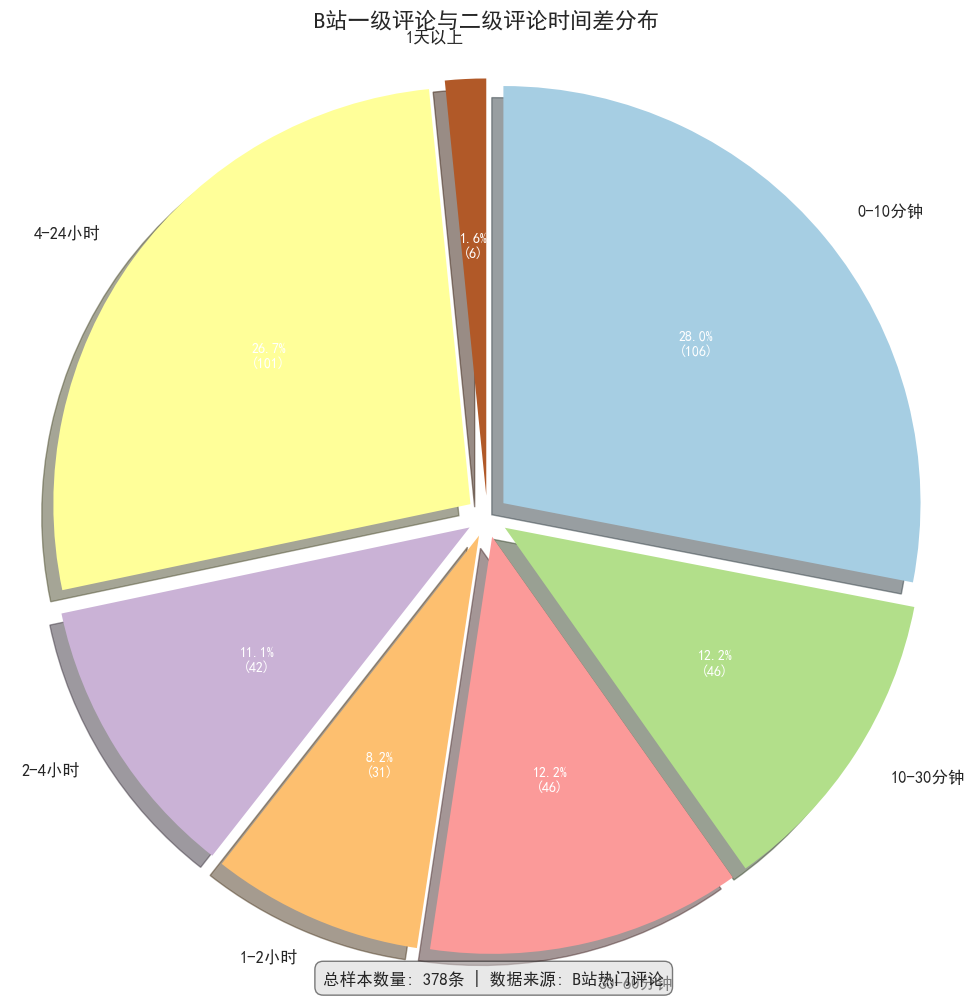

2025-03-23 16:24:36,658 - INFO - 评论时间差分布图绘制完成


0-10分钟     106
10-30分钟     46
30-60分钟     46
1-2小时       31
2-4小时       42
4-24小时     101
1天以上         6
Name: count, dtype: int64

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

class CommentTimeAnalyzer:
    """B站评论时间差分析器，分析一级评论与二级评论的回复时间间隔"""
    
    def __init__(self, data_manager):
        """初始化时间分析器
        
        Args:
            data_manager: BilibiliDataManager实例
        """
        self.data_manager = data_manager
        self.logger = data_manager.logger
        
        # 设置matplotlib中文显示
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        self.logger.info("评论时间差分析器初始化完成")
    
    def analyze_reply_time_differences(self):
        """分析一级评论与二级评论之间的时间差"""
        if self.data_manager.comments_df.empty:
            self.logger.warning("评论数据为空，请先加载数据")
            return None
            
        self.logger.info("开始分析评论时间差")
        
        # 过滤出一级和二级评论
        primary_comments = self.data_manager.comments_df[
            self.data_manager.comments_df['评论层级'] == '一级评论'
        ].copy()
        secondary_comments = self.data_manager.comments_df[
            self.data_manager.comments_df['评论层级'] == '二级评论'
        ].copy()
        
        # 创建用户昵称到回复时间的映射
        primary_time_map = dict(zip(primary_comments['用户昵称'], primary_comments['回复时间']))
        
        # 计算时间差（单位：分钟）
        time_diffs = []
        
        for _, row in secondary_comments.iterrows():
            replied_user = row['被回复用户']
            reply_time = row['回复时间']
            
            if replied_user in primary_time_map:
                primary_time = primary_time_map[replied_user]
                # 计算时间差（分钟）
                time_diff = (reply_time - primary_time).total_seconds() / 60
                time_diffs.append(time_diff)
        
        self.logger.info(f"时间差分析完成，共找到 {len(time_diffs)} 个有效时间差")
        return time_diffs
    
    def plot_time_diff_distribution(self):
        """绘制评论时间差分布饼状图"""
        self.logger.info("开始绘制评论时间差分布图")
        
        # 获取时间差数据
        all_time_diffs = self.analyze_reply_time_differences()
        if not all_time_diffs:
            self.logger.warning("没有找到有效的时间差数据")
            return
            
        # 将时间差分为几个区间
        bins = [0, 10, 30, 60, 120, 240, 1440, float('inf')]
        labels = ['0-10分钟', '10-30分钟', '30-60分钟', '1-2小时', '2-4小时', '4-24小时', '1天以上']
        time_diff_categories = pd.cut(all_time_diffs, bins=bins, labels=labels, right=False)
        
        # 统计每个区间的数量
        time_diff_counts = pd.value_counts(time_diff_categories, sort=False)
        
        # 绘制饼状图
        plt.figure(figsize=(10, 10))
        
        # 在饼状图中显示每部分的数量和百分比
        wedges, texts, autotexts = plt.pie(
            time_diff_counts, 
            labels=time_diff_counts.index,
            autopct=lambda p: f'{p:.1f}%\n({int(p * sum(time_diff_counts) / 100)})',
            startangle=90,
            counterclock=False,
            shadow=True,
            explode=[0.05] * len(time_diff_counts),  # 稍微分离各部分
            textprops={'fontsize': 12},
            colors=plt.cm.Paired(np.linspace(0, 1, len(time_diff_counts)))
        )
        
        # 调整文本样式
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontsize(10)
            autotext.set_fontweight('bold')
        
        plt.title('B站一级评论与二级评论时间差分布', fontsize=16, pad=20)
        plt.axis('equal')  # 确保饼图是圆形
        
        # 在图下方标注总样本数量
        total_samples = len(all_time_diffs)
        plt.figtext(
            0.5, 0.01, 
            f'总样本数量: {total_samples}条 | 数据来源: B站热门评论', 
            ha='center', 
            fontsize=12,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgrey', alpha=0.5)
        )
        
        plt.tight_layout()
        plt.show()
        
        self.logger.info("评论时间差分布图绘制完成")
        return time_diff_counts

# 创建时间分析器并绘制时间差分布图
time_analyzer = CommentTimeAnalyzer(bilibili_data)
time_analyzer.plot_time_diff_distribution()

### 2.热度曲线
热度曲线展示了B站评论区互动活跃度随时间的变化趋势，直观呈现出评论热度的生命周期。这条曲线通过对视频发布后各时间段内的点赞数和评论数加权计算得出，反映了用户参与度的时间动态特性。

通过分析热度曲线，我们可以揭示：
- 评论热度的峰值时段，表明最大曝光和互动时机
- 热度衰减的速率，反映内容的持续影响力
- 周期性波动模式，可能与用户作息或平台推荐算法相关
- 长尾效应特征，即少数评论如何在长时间内持续获得互动

这一分析对于理解B站内容传播规律具有重要价值，可帮助创作者把握最佳内容发布节奏，也为平台优化推荐机制提供数据依据。通过热度曲线，我们能够量化评论区活跃度的时间特征，进而预测内容互动表现和生命周期。

2025-03-23 16:24:40,747 - INFO - 评论时间差热度分析器初始化完成
2025-03-23 16:24:40,748 - INFO - 开始绘制评论时间差热度图
2025-03-23 16:24:40,749 - INFO - 开始计算评论时间差数据
2025-03-23 16:24:40,750 - INFO - 找到 492 条一级评论和 378 条二级评论
2025-03-23 16:24:40,772 - INFO - 时间差数据计算完成，共生成 378 条有效时间差记录
C:\Users\33223\AppData\Local\Temp\ipykernel_29588\3324620677.py:171: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  like_response = time_diff_df.groupby('like_category')['time_diff_minutes'].agg(['mean', 'count']).reset_index()


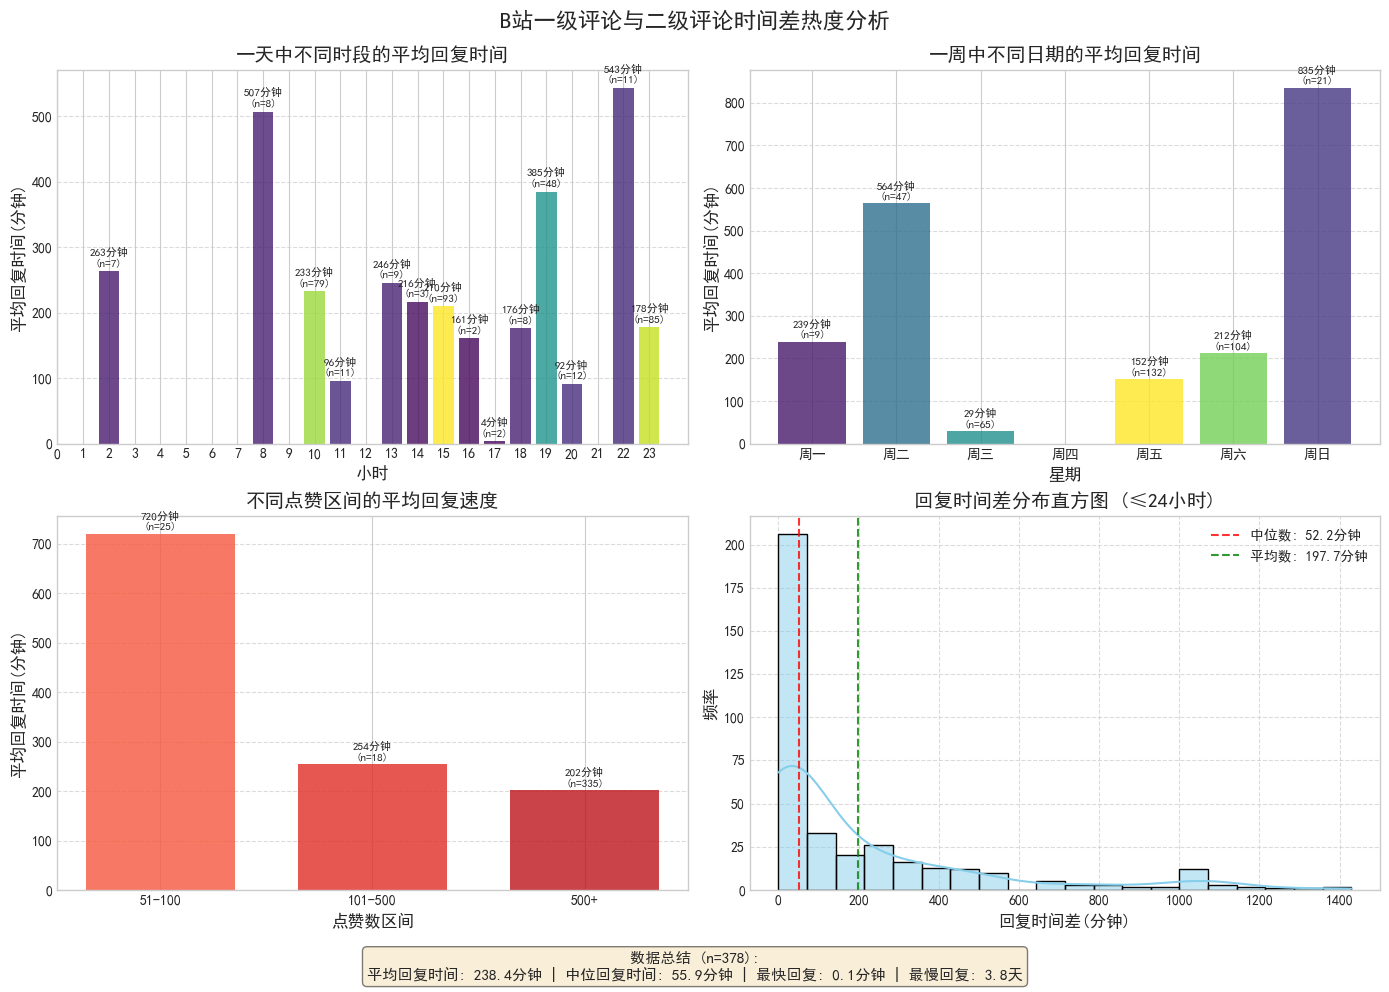

2025-03-23 16:24:41,497 - INFO - 评论时间差热度图绘制完成


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import seaborn as sns

class ReplyTimeDifferenceAnalyzer:
    """B站评论时间差热度分析器，分析一级评论与二级评论的时间差热度分布"""
    
    def __init__(self, data_manager):
        """初始化时间差热度分析器
        
        Args:
            data_manager: BilibiliDataManager实例
        """
        self.data_manager = data_manager
        self.logger = data_manager.logger
        
        # 设置matplotlib中文显示
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        self.logger.info("评论时间差热度分析器初始化完成")
    
    def analyze_reply_time_differences(self):
        """计算一级评论与二级评论之间的时间差数据"""
        if self.data_manager.comments_df.empty:
            self.logger.warning("评论数据为空，请先加载数据")
            return None
            
        self.logger.info("开始计算评论时间差数据")
        
        # 过滤出一级和二级评论
        df = self.data_manager.comments_df
        primary_comments = df[df['评论层级'] == '一级评论'].copy()
        secondary_comments = df[df['评论层级'] == '二级评论'].copy()
        
        self.logger.info(f"找到 {len(primary_comments)} 条一级评论和 {len(secondary_comments)} 条二级评论")
        
        # 创建用户昵称到回复时间和点赞数的映射
        primary_data = {}
        for _, row in primary_comments.iterrows():
            primary_data[row['用户昵称']] = {
                'time': row['回复时间'],
                'likes': row['点赞数量'],
                'video_id': row['视频ID']
            }
        
        # 计算时间差并组织成DataFrame
        time_diff_data = []
        
        for _, row in secondary_comments.iterrows():
            replied_user = row['被回复用户']
            reply_time = row['回复时间']
            video_id = row['视频ID']
            
            if replied_user in primary_data and primary_data[replied_user]['video_id'] == video_id:
                primary_time = primary_data[replied_user]['time']
                primary_likes = primary_data[replied_user]['likes']
                
                # 计算时间差（分钟）
                time_diff_minutes = (reply_time - primary_time).total_seconds() / 60
                
                # 收集数据
                time_diff_data.append({
                    'primary_time': primary_time,
                    'reply_time': reply_time,
                    'time_diff_minutes': time_diff_minutes,
                    'primary_likes': primary_likes,
                    'video_id': video_id,
                    'hour_of_day': primary_time.hour,
                    'day_of_week': primary_time.dayofweek  # 0=周一, 6=周日
                })
        
        # 转换为DataFrame
        if not time_diff_data:
            self.logger.warning("未找到有效的时间差数据")
            return None
            
        time_diff_df = pd.DataFrame(time_diff_data)
        self.logger.info(f"时间差数据计算完成，共生成 {len(time_diff_df)} 条有效时间差记录")
        
        return time_diff_df
    
    def plot_time_diff_heatmap(self, figsize=(14, 10)):
        """绘制评论时间差热度图"""
        self.logger.info("开始绘制评论时间差热度图")
        
        # 获取时间差数据
        time_diff_df = self.analyze_reply_time_differences()
        if time_diff_df is None:
            return
        
        # 创建2x2子图布局
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        
        # 1. 按一天中的小时分布热力图
        ax1 = axes[0, 0]
        # 按小时和响应时间分组计算平均响应时间
        hour_response = time_diff_df.groupby('hour_of_day')['time_diff_minutes'].agg(['mean', 'count']).reset_index()
        # 绘制条形图
        bars = ax1.bar(
            hour_response['hour_of_day'],
            hour_response['mean'],
            width=0.8,
            color=plt.cm.viridis(hour_response['count']/hour_response['count'].max()),
            alpha=0.8
        )
        ax1.set_title('一天中不同时段的平均回复时间', fontsize=14)
        ax1.set_xlabel('小时', fontsize=12)
        ax1.set_ylabel('平均回复时间(分钟)', fontsize=12)
        ax1.set_xticks(range(0, 24))
        ax1.grid(axis='y', linestyle='--', alpha=0.7)
        
        # 添加数据标签
        for bar, count in zip(bars, hour_response['count']):
            height = bar.get_height()
            ax1.text(
                bar.get_x() + bar.get_width()/2.,
                height + 5,
                f'{height:.0f}分钟\n(n={count})',
                ha='center', va='bottom',
                fontsize=8
            )
        
        # 2. 按周几分布热力图
        ax2 = axes[0, 1]
        day_names = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
        # 按周几和响应时间分组计算平均响应时间
        day_response = time_diff_df.groupby('day_of_week')['time_diff_minutes'].agg(['mean', 'count']).reset_index()
        # 确保所有天都有数据
        all_days = pd.DataFrame({'day_of_week': range(7)})
        day_response = pd.merge(all_days, day_response, on='day_of_week', how='left').fillna(0)
        # 绘制条形图
        bars = ax2.bar(
            day_response['day_of_week'],
            day_response['mean'],
            width=0.8,
            color=plt.cm.viridis(day_response['count']/day_response['count'].max()),
            alpha=0.8
        )
        ax2.set_title('一周中不同日期的平均回复时间', fontsize=14)
        ax2.set_xlabel('星期', fontsize=12)
        ax2.set_ylabel('平均回复时间(分钟)', fontsize=12)
        ax2.set_xticks(range(7))
        ax2.set_xticklabels(day_names)
        ax2.grid(axis='y', linestyle='--', alpha=0.7)
        
        # 添加数据标签
        for bar, count in zip(bars, day_response['count']):
            height = bar.get_height()
            if height > 0:  # 只为有数据的条添加标签
                ax2.text(
                    bar.get_x() + bar.get_width()/2.,
                    height + 5,
                    f'{height:.0f}分钟\n(n={int(count)})',
                    ha='center', va='bottom',
                    fontsize=8
                )
        
        # 3. 热门评论回复速度分析
        ax3 = axes[1, 0]
        # 将点赞数分为几个区间
        time_diff_df['like_category'] = pd.cut(
            time_diff_df['primary_likes'],
            bins=[0, 10, 50, 100, 500, float('inf')],
            labels=['0-10', '11-50', '51-100', '101-500', '500+']
        )
        # 计算每个点赞区间的平均回复时间
        like_response = time_diff_df.groupby('like_category')['time_diff_minutes'].agg(['mean', 'count']).reset_index()
        
        bars = ax3.bar(
            like_response['like_category'],
            like_response['mean'],
            width=0.7,
            color=plt.cm.Reds(np.linspace(0.3, 0.8, len(like_response))),
            alpha=0.8
        )
        ax3.set_title('不同点赞区间的平均回复速度', fontsize=14)
        ax3.set_xlabel('点赞数区间', fontsize=12)
        ax3.set_ylabel('平均回复时间(分钟)', fontsize=12)
        ax3.grid(axis='y', linestyle='--', alpha=0.7)
        
        # 添加数据标签
        for bar, count in zip(bars, like_response['count']):
            height = bar.get_height()
            ax3.text(
                bar.get_x() + bar.get_width()/2.,
                height + 5,
                f'{height:.0f}分钟\n(n={count})',
                ha='center', va='bottom',
                fontsize=8
            )
        
        # 4. 回复时间差分布直方图
        ax4 = axes[1, 1]
        # 过滤掉极端值以便更好地可视化
        filtered_diffs = time_diff_df[time_diff_df['time_diff_minutes'] <= 1440]  # 不超过1天
        
        # 绘制直方图
        sns.histplot(
            filtered_diffs['time_diff_minutes'],
            bins=20,
            kde=True,
            color='skyblue',
            ax=ax4
        )
        ax4.set_title('回复时间差分布直方图 (≤24小时)', fontsize=14)
        ax4.set_xlabel('回复时间差(分钟)', fontsize=12)
        ax4.set_ylabel('频率', fontsize=12)
        ax4.grid(True, linestyle='--', alpha=0.7)
        
        # 在图上标记中位数和平均数
        median_time = filtered_diffs['time_diff_minutes'].median()
        mean_time = filtered_diffs['time_diff_minutes'].mean()
        
        ax4.axvline(median_time, color='red', linestyle='--', alpha=0.8, label=f'中位数: {median_time:.1f}分钟')
        ax4.axvline(mean_time, color='green', linestyle='--', alpha=0.8, label=f'平均数: {mean_time:.1f}分钟')
        ax4.legend()
        
        # 主标题
        fig.suptitle('B站一级评论与二级评论时间差热度分析', fontsize=16, y=0.98)
        
        # 添加总结统计信息
        summary_text = (
            f"数据总结 (n={len(time_diff_df)}):\n"
            f"平均回复时间: {time_diff_df['time_diff_minutes'].mean():.1f}分钟 | "
            f"中位回复时间: {time_diff_df['time_diff_minutes'].median():.1f}分钟 | "
            f"最快回复: {time_diff_df['time_diff_minutes'].min():.1f}分钟 | "
            f"最慢回复: {time_diff_df['time_diff_minutes'].max()/60/24:.1f}天"
        )
        
        fig.text(0.5, 0.01, summary_text, ha='center', fontsize=11, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.92, bottom=0.10)
        plt.show()
        
        self.logger.info("评论时间差热度图绘制完成")
        return self

# 创建时间差热度分析器并绘制热度图
time_diff_analyzer = ReplyTimeDifferenceAnalyzer(bilibili_data)
time_diff_analyzer.plot_time_diff_heatmap(figsize=(14, 10))

## 六.NLP特征提取

自然语言处理(NLP)特征提取是本分析的核心技术，通过对B站评论文本进行深度挖掘，我们能够量化评论的情感倾向、语言特点和内容特征。在这一部分，我们运用中文情感分析模型对每条评论进行情感极性评分，并研究这些情感指数与获得点赞数之间的潜在关系。

主要的NLP特征包括：
- **情感极性**：评论的积极、消极或中性程度量化评分
- **情感强度**：情感表达的强烈程度
- **文本复杂度**：包括句法复杂性、词汇丰富度等指标
- **特征词频统计**：高频词、特殊表达和表情符号的使用模式

通过分析这些NLP特征与点赞数的关系，我们可以揭示：
- 积极或消极评论哪种更容易获得高点赞
- 情感表达强度与用户共鸣度的关联
- 评论长度、复杂度与受欢迎程度的相关性
- B站特有的表达方式（如专业术语、梗）对点赞的影响

这一分析不仅有助于理解B站用户情感表达偏好，还能为创作者提供有关如何撰写更具互动性评论的洞察。通过机器学习模型，我们将尝试预测评论的潜在点赞数，为理解B站社区互动规律提供数据支持。

### 1.点赞数与情感指数的关系



2025-03-23 16:25:04,018 - INFO - 情感分析器初始化完成
2025-03-23 16:25:04,019 - INFO - 开始绘制情感分布图
2025-03-23 16:25:04,019 - INFO - 开始对评论内容进行情感分析
2025-03-23 16:25:07,158 - INFO - 情感分析完成，共处理 870 条评论
C:\Users\33223\AppData\Local\Temp\ipykernel_29588\5561745.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_comments.groupby(['LikesCategory', 'SentimentRange']).size().unstack(fill_value=0)


<Figure size 1200x800 with 0 Axes>

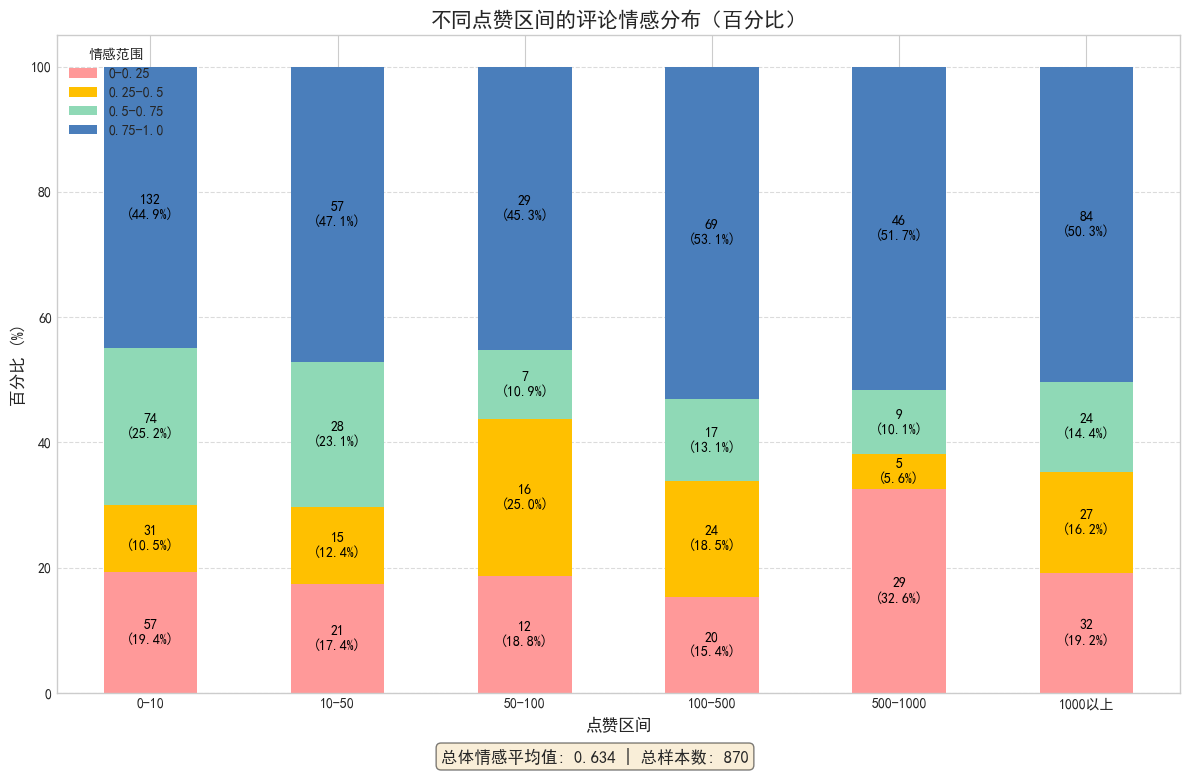

2025-03-23 16:25:07,367 - INFO - 情感分布图绘制完成


SentimentRange,0-0.25,0.25-0.5,0.5-0.75,0.75-1.0
LikesCategory,,,,
0-10,19.387755,10.544218,25.170068,44.897959
10-50,17.355372,12.396694,23.140496,47.107438
50-100,18.750000,25.000000,10.937500,45.312500
100-500,15.384615,18.461538,13.076923,53.076923
500-1000,32.584270,5.617978,10.112360,51.685393
1000以上,19.161677,16.167665,14.371257,50.299401


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from snownlp import SnowNLP

class SentimentAnalyzer:
    """B站评论情感分析器，分析评论情感与点赞数的关系"""
    
    def __init__(self, data_manager):
        """初始化情感分析器
        
        Args:
            data_manager: BilibiliDataManager实例
        """
        self.data_manager = data_manager
        self.logger = data_manager.logger
        
        # 设置matplotlib中文显示
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        self.logger.info("情感分析器初始化完成")
    
    def analyze_sentiment(self):
        """对评论内容进行情感分析"""
        if self.data_manager.comments_df.empty:
            self.logger.warning("评论数据为空，请先加载数据")
            return None
            
        self.logger.info("开始对评论内容进行情感分析")
        
        # 从数据中提取评论内容和点赞数
        data = []
        for _, row in self.data_manager.comments_df.iterrows():
            try:
                comment_content = row['评论内容']
                likes = row['点赞数量']
                
                # 使用SnowNLP进行情感分析
                sentiment = SnowNLP(comment_content).sentiments  # 情感得分(0-1)
                data.append((likes, sentiment))
            except Exception as e:
                self.logger.warning(f"处理评论时出错: {e}")
        
        self.logger.info(f"情感分析完成，共处理 {len(data)} 条评论")
        return data
    
    def visualize_sentiment_distribution(self):
        """可视化不同点赞区间的情感分布"""
        self.logger.info("开始绘制情感分布图")
        
        sentiment_data = self.analyze_sentiment()
        if not sentiment_data:
            return
        
        # 将点赞数分为几个区间
        bins = [0, 10, 50, 100, 500, 1000, float('inf')]
        labels = ['0-10', '10-50', '50-100', '100-500', '500-1000', '1000以上']
        likes_categories = pd.cut([x[0] for x in sentiment_data], bins=bins, labels=labels, right=False)
        
        # 创建DataFrame
        df_comments = pd.DataFrame(sentiment_data, columns=['Likes', 'Sentiment'])
        df_comments['LikesCategory'] = likes_categories
        
        # 将情感指数划分为四个范围
        sentiment_bins = [0, 0.25, 0.5, 0.75, 1.0]
        sentiment_labels = ['0-0.25', '0.25-0.5', '0.5-0.75', '0.75-1.0']
        df_comments['SentimentRange'] = pd.cut(df_comments['Sentiment'], bins=sentiment_bins, labels=sentiment_labels, right=False)
        
        # 按点赞区间和情感范围分组并统计评论数量
        grouped = df_comments.groupby(['LikesCategory', 'SentimentRange']).size().unstack(fill_value=0)
        
        # 计算每个点赞区间的总评论数
        grouped_percentage = grouped.div(grouped.sum(axis=1), axis=0) * 100  # 转换为百分比
        
        # 绘制堆叠条形图
        plt.figure(figsize=(12, 8))
        
        # 绘制堆叠条形图（百分比）
        grouped_percentage.plot(
            kind='bar', 
            stacked=True, 
            color=['#FF9999', '#FFC000', '#8FD9B6', '#4A7EBB'], 
            figsize=(12, 8)
        )
        
        # 添加图表信息
        plt.xlabel('点赞区间', fontsize=12)
        plt.ylabel('百分比 (%)', fontsize=12)
        plt.title('不同点赞区间的评论情感分布（百分比）', fontsize=15)
        plt.xticks(rotation=0)
        plt.legend(title='情感范围', loc='upper left')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # 在每个堆叠条形上显示样本数量和百分比
        for i, (index, row) in enumerate(grouped.iterrows()):
            total = row.sum()  # 当前点赞区间的总评论数
            cumulative_percentage = 0  # 累计百分比
            for j, value in enumerate(row):
                percentage = grouped_percentage.iloc[i, j]
                cumulative_percentage += percentage
                plt.text(
                    i, cumulative_percentage - percentage / 2,  # 在堆叠条形的中间位置
                    f'{int(value)}\n({percentage:.1f}%)',  # 显示样本数量和百分比
                    ha='center', va='center', fontsize=10, color='black'
                )
        
        # 添加总体情感统计
        avg_sentiment = np.mean([x[1] for x in sentiment_data])
        plt.figtext(
            0.5, 0.01, 
            f"总体情感平均值: {avg_sentiment:.3f} | 总样本数: {len(sentiment_data)}", 
            ha='center', 
            fontsize=12,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        )
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()
        
        self.logger.info("情感分布图绘制完成")
        return grouped_percentage

# 创建情感分析器并绘制情感分布图
sentiment_analyzer = SentimentAnalyzer(bilibili_data)
sentiment_analyzer.visualize_sentiment_distribution()

### 2.点赞数与信息熵的关系
网络用语密度
#### (1)生成密度词云

信息熵分析是衡量评论文本复杂度和信息丰富程度的有效指标，而网络用语密度则反映了B站特有的社区语言文化。本部分通过计算每条评论的信息熵和网络用语使用频率，探究这些文本特征与点赞数的潜在关联。

密度词云是一种直观的可视化方式，通过字体大小和颜色变化，展示B站热门评论中最常见的网络用语、流行梗和特殊表达。词云中的词汇大小与其在高赞评论中出现的频率成正比，颜色深浅则反映其与点赞数的相关强度。

通过分析这一词云图，我们可以发现：
- B站社区特有的"圈内语言"，这些表达往往成为获得共鸣的文化密码
- 当前流行的网络用语和梗的使用趋势，反映平台文化特性
- 不同话题或视频类型下特有的专业术语和表达方式
- 高点赞评论中使用的特殊表情符号和修辞手法

这一分析不仅揭示了B站独特的社区语言生态，也为内容创作者提供了关于如何使用合适的语言风格来增强社区共鸣的实用指导。通过对比不同时期的词云变化，我们还能观察B站用户语言表达的演变趋势，反映整体网络文化的发展动态。

2025-03-23 16:25:00,236 - INFO - 词云生成器初始化完成
2025-03-23 16:25:00,236 - INFO - 开始生成词云
2025-03-23 16:25:00,237 - INFO - 开始从评论中提取词语和表情符号
Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\33223\AppData\Local\Temp\jieba.cache
Loading model cost 0.490 seconds.
Prefix dict has been built successfully.
2025-03-23 16:25:00,819 - INFO - 提取完成：找到 3618 个有效词语，64 个表情符号


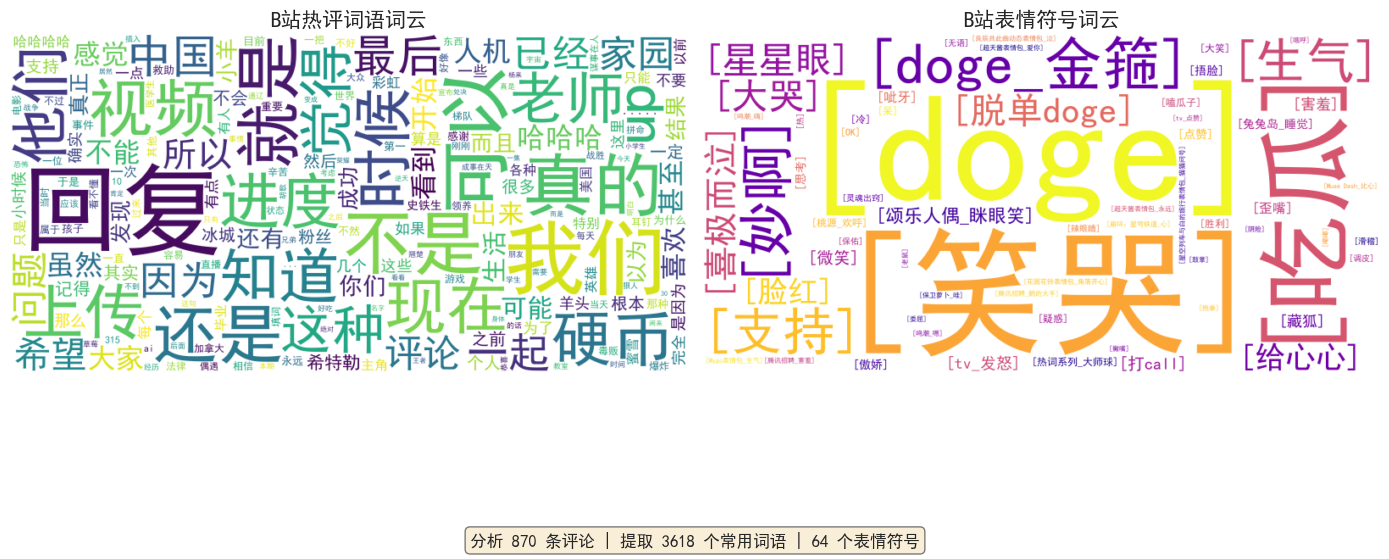

2025-03-23 16:25:02,438 - INFO - 词云生成完成


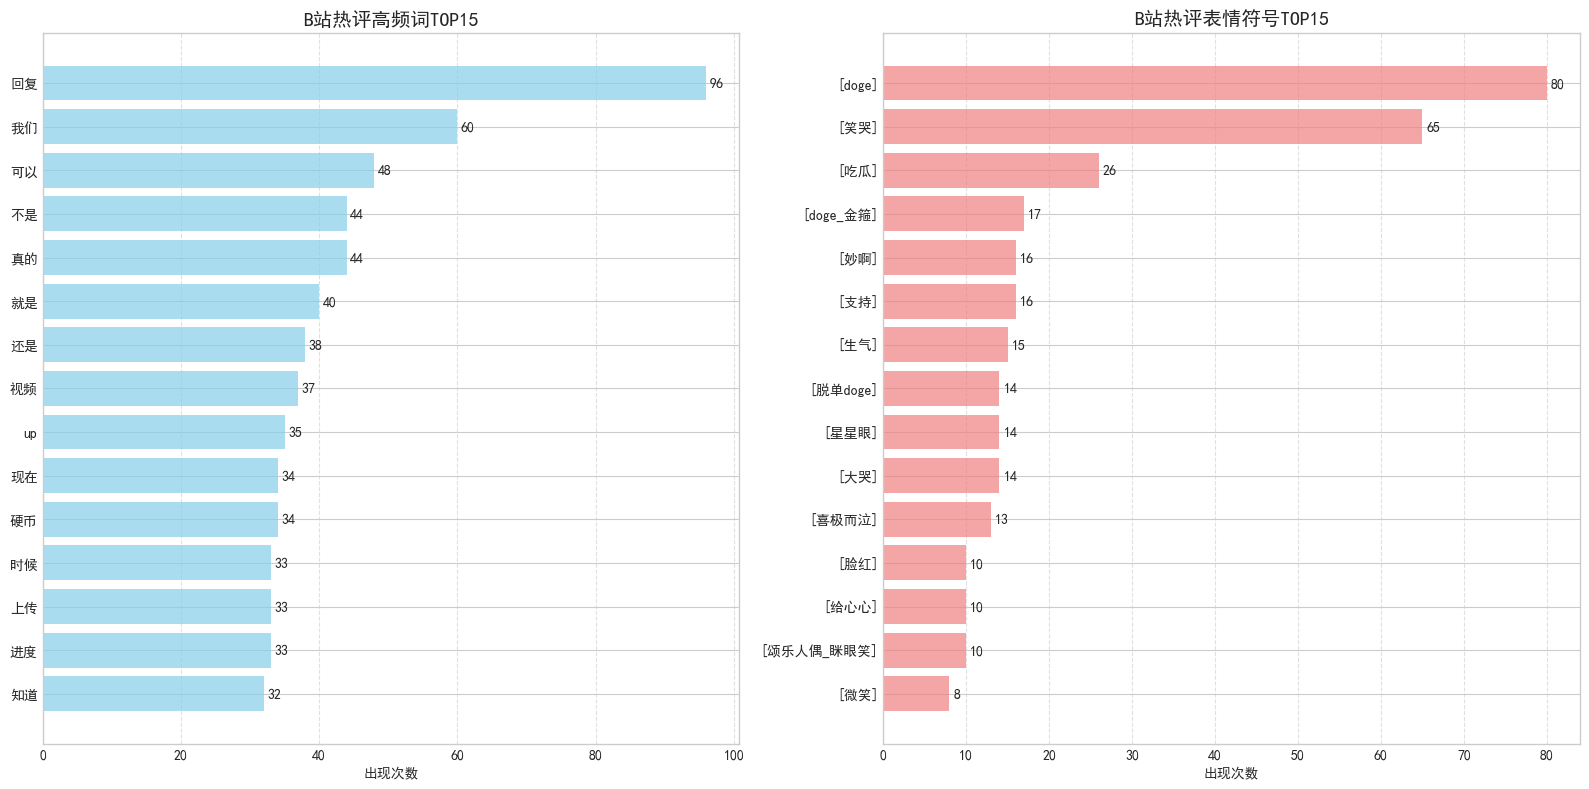

2025-03-23 16:25:02,685 - INFO - 热门排行榜显示完成，展示了TOP15词语和表情


In [16]:
import jieba
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import pandas as pd
import numpy as np

class WordCloudGenerator:
    """B站评论词云生成器，分析评论内容词频和表情符号使用情况"""
    
    def __init__(self, data_manager):
        """初始化词云生成器
        
        Args:
            data_manager: BilibiliDataManager实例
        """
        self.data_manager = data_manager
        self.logger = data_manager.logger
        
        # 设置matplotlib中文显示
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        # 设置停用词表
        self.stopwords = set([
            "的", "了", "和", "是", "我", "在", "有", "也", "就", "不", "人", "都", 
            "一个", "上", "很", "到", "说", "要", "去", "你", "会", "着", "没有", "看", 
            "好", "自己", "这", "吧", "啊", "吗", "啦", "呢", "哦", "嘛", "个", "把",
            "还", "给", "怎么", "什么", "这个", "那个", "他", "她", "它", "让", "得",
            "为", "对", "能", "这样", "或者", "但是", "这么", "再", "一下", "一样", "但"
        ])
        
        self.logger.info("词云生成器初始化完成")
    
    def extract_words_and_emojis(self):
        """从评论数据中提取词语和表情符号"""
        if self.data_manager.comments_df.empty:
            self.logger.warning("评论数据为空，请先加载数据")
            return None, None
            
        self.logger.info("开始从评论中提取词语和表情符号")
        
        all_words = []
        all_emojis = []
        
        # 遍历评论内容
        for comment in self.data_manager.comments_df['评论内容']:
            if not isinstance(comment, str) or not comment:
                continue
                
            # 提取表情符号（用 [] 括起来的内容）
            emojis = re.findall(r'\[.*?\]', comment)
            all_emojis.extend(emojis)
            
            # 去除表情符号后进行分词
            comment_without_emojis = re.sub(r'\[.*?\]', '', comment)
            words = jieba.lcut(comment_without_emojis)
            all_words.extend(words)
        
        # 统计词频
        word_counts = Counter(all_words)
        emoji_counts = Counter(all_emojis)
        
        # 过滤停用词和单字词
        filtered_word_counts = {word: count for word, count in word_counts.items() 
                              if word not in self.stopwords and len(word) > 1}
        
        self.logger.info(f"提取完成：找到 {len(filtered_word_counts)} 个有效词语，{len(emoji_counts)} 个表情符号")
        return filtered_word_counts, emoji_counts
    
    def generate_wordclouds(self, figsize=(16, 8), max_words=200):
        """生成并展示词云"""
        self.logger.info("开始生成词云")
        
        word_counts, emoji_counts = self.extract_words_and_emojis()
        if not word_counts:
            return
        
        # 创建画布
        plt.figure(figsize=figsize)
        
        # 生成普通词语的词云
        wordcloud_words = WordCloud(
            font_path="simhei.ttf",  # 确保支持中文
            width=800,
            height=400,
            background_color="white",
            max_words=max_words,
            colormap='viridis',
            contour_width=1,
            contour_color='steelblue'
        ).generate_from_frequencies(word_counts)
        
        # 生成表情符号的词云
        wordcloud_emojis = WordCloud(
            font_path="simhei.ttf",
            width=800,
            height=400,
            background_color="white",
            max_words=max_words,
            colormap='plasma',
            contour_width=1,
            contour_color='steelblue'
        ).generate_from_frequencies(emoji_counts)
        
        # 显示普通词语的词云
        plt.subplot(1, 2, 1)
        plt.imshow(wordcloud_words, interpolation="bilinear")
        plt.axis("off")
        plt.title("B站热评词语词云", fontsize=15)
        
        # 显示表情符号的词云
        plt.subplot(1, 2, 2)
        plt.imshow(wordcloud_emojis, interpolation="bilinear")
        plt.axis("off")
        plt.title("B站表情符号词云", fontsize=15)
        
        # 添加统计信息
        plt.figtext(
            0.5, 0.01, 
            f"分析 {len(self.data_manager.comments_df)} 条评论 | 提取 {len(word_counts)} 个常用词语 | {len(emoji_counts)} 个表情符号",
            ha='center',
            fontsize=12,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        )
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()
        
        self.logger.info("词云生成完成")
        
        # 显示热门词语和表情排行榜
        self._show_top_items(word_counts, emoji_counts)
        
        return self
    
    def _show_top_items(self, word_counts, emoji_counts, top_n=15):
        """显示热门词语和表情排行榜"""
        top_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]
        top_emojis = sorted(emoji_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        
        # 热门词语排行榜
        words = [item[0] for item in top_words]
        word_counts_values = [item[1] for item in top_words]
        
        ax1.barh(range(len(words)), word_counts_values, color='skyblue', alpha=0.7)
        ax1.set_yticks(range(len(words)))
        ax1.set_yticklabels(words)
        ax1.invert_yaxis()  # 最高频的在顶部
        ax1.set_xlabel('出现次数')
        ax1.set_title('B站热评高频词TOP15', fontsize=14)
        ax1.grid(axis='x', linestyle='--', alpha=0.6)
        
        # 在柱状图上添加数值
        for i, count in enumerate(word_counts_values):
            ax1.text(count + 0.5, i, str(count), va='center', fontsize=10)
        
        # 热门表情排行榜
        emojis = [item[0] for item in top_emojis]
        emoji_counts_values = [item[1] for item in top_emojis]
        
        ax2.barh(range(len(emojis)), emoji_counts_values, color='lightcoral', alpha=0.7)
        ax2.set_yticks(range(len(emojis)))
        ax2.set_yticklabels(emojis)
        ax2.invert_yaxis()  # 最高频的在顶部
        ax2.set_xlabel('出现次数')
        ax2.set_title('B站热评表情符号TOP15', fontsize=14)
        ax2.grid(axis='x', linestyle='--', alpha=0.6)
        
        # 在柱状图上添加数值
        for i, count in enumerate(emoji_counts_values):
            ax2.text(count + 0.5, i, str(count), va='center', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        self.logger.info(f"热门排行榜显示完成，展示了TOP{top_n}词语和表情")

# 创建词云生成器并生成可视化
word_cloud_gen = WordCloudGenerator(bilibili_data)
word_cloud_gen.generate_wordclouds(figsize=(14, 7))

#### (2)评论长度与点赞数的关系

评论长度是一个重要却常被忽视的文本特征，本部分通过散点图和回归分析，探究B站评论字数与获得点赞数之间的潜在关联。这一分析旨在回答一个简单却关键的问题：在B站社区中，是简短精炼还是详尽阐述的评论更受欢迎？

通过对所有爬取评论的字符长度与点赞数进行对比分析，我们可以发现：
- 最佳评论长度区间，即获得高点赞的评论通常具有的字数范围
- 超长评论的点赞表现，检验用户对深度内容的接受度
- 极简评论（如一句话评论）的点赞获取效率
- 不同视频类型下最优评论长度的差异性

这种分析对于理解B站用户阅读偏好具有重要价值。它揭示了平台用户对信息量的容忍度和期望值，反映了当代网络交流中注意力分配的特点。对于内容创作者而言，这些发现可以指导评论互动策略的优化，帮助找到表达完整性和简洁性之间的最佳平衡点。

图表采用散点图加局部多项式回归拟合曲线的形式，直观展示评论长度和点赞数的非线性关系，并标记出点赞峰值对应的最佳长度区间，为创作者提供明确的参考指标。

2025-03-23 16:25:12,615 - INFO - 评论长度分析器初始化完成
2025-03-23 16:25:12,616 - INFO - 开始绘制评论长度与点赞数关系图
2025-03-23 16:25:12,616 - INFO - 开始分析评论长度与点赞数的关系
C:\Users\33223\AppData\Local\Temp\ipykernel_29588\1575653503.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_stats = df.groupby('LengthRange').agg({
C:\Users\33223\AppData\Local\Temp\ipykernel_29588\1575653503.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_grouped = df.groupby(['LengthRange', '评论层级']).agg({
2025-03-23 16:25:12,641 - INFO - 评论长度分析完成，共处理 870 条评论


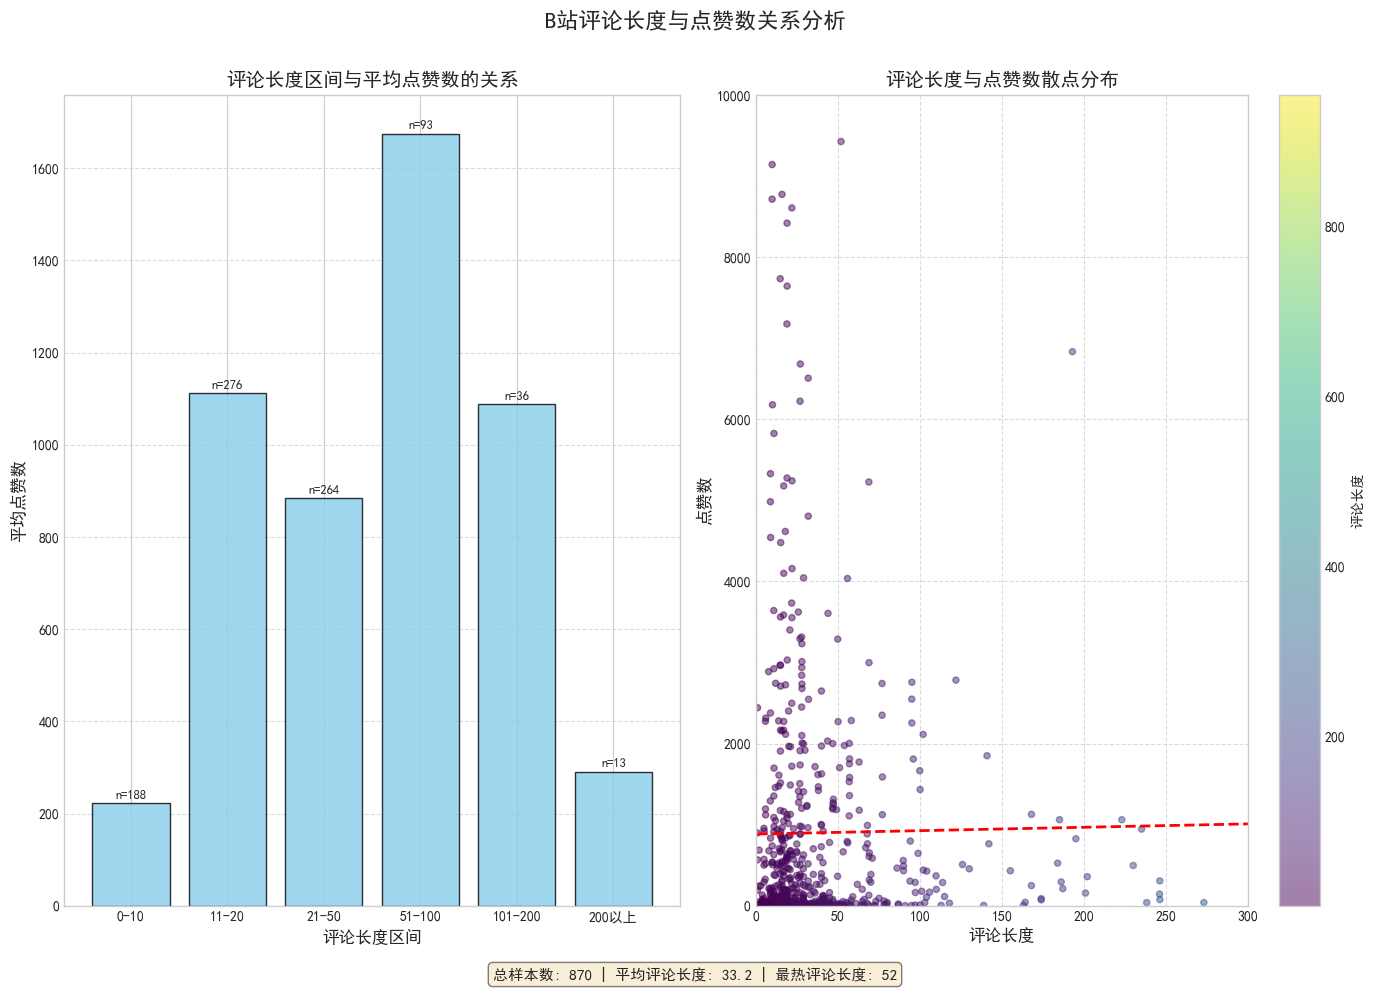

2025-03-23 16:25:12,884 - INFO - 评论长度与点赞数关系图绘制完成


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

class CommentLengthAnalyzer:
    """B站评论长度分析器，分析评论长度与点赞数的关系"""
    
    def __init__(self, data_manager):
        """初始化评论长度分析器
        
        Args:
            data_manager: BilibiliDataManager实例
        """
        self.data_manager = data_manager
        self.logger = data_manager.logger
        
        # 设置matplotlib中文显示
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        self.logger.info("评论长度分析器初始化完成")
    
    def analyze_comment_length_and_likes(self):
        """分析评论长度与点赞数的关系"""
        if self.data_manager.comments_df.empty:
            self.logger.warning("评论数据为空，请先加载数据")
            return None
            
        self.logger.info("开始分析评论长度与点赞数的关系")
        
        # 创建一个新的DataFrame用于分析
        df = pd.DataFrame()
        
        # 处理评论内容，计算长度
        comments_with_length = []
        
        for _, row in self.data_manager.comments_df.iterrows():
            comment_content = row['评论内容']
            likes = row['点赞数量']
            
            if isinstance(comment_content, str) and likes is not None:
                # 使用正则表达式处理表情符号，将每个表情符号视为一个字符
                comment_content_cleaned = re.sub(r'\[.*?\]', 'E', comment_content)
                comment_length = len(comment_content_cleaned)
                
                comments_with_length.append({
                    'CommentLength': comment_length,
                    'Likes': likes,
                    '评论层级': row['评论层级']
                })
        
        df = pd.DataFrame(comments_with_length)
        
        # 将评论长度划分为不同区间
        bins = [0, 10, 20, 50, 100, 200, float('inf')]
        labels = ['0-10', '11-20', '21-50', '51-100', '101-200', '200以上']
        df['LengthRange'] = pd.cut(df['CommentLength'], bins=bins, labels=labels, right=False)
        
        # 按评论长度区间分组并计算统计值
        grouped_stats = df.groupby('LengthRange').agg({
            'Likes': ['mean', 'median', 'count', 'max']
        })
        
        # 重命名列以便于访问
        grouped_stats.columns = ['平均点赞数', '中位点赞数', '评论数量', '最大点赞数']
        grouped_stats = grouped_stats.reset_index()
        
        # 分别计算一级和二级评论的统计
        level_grouped = df.groupby(['LengthRange', '评论层级']).agg({
            'Likes': ['mean', 'count']
        })
        
        self.logger.info(f"评论长度分析完成，共处理 {len(df)} 条评论")
        
        return {
            'all_data': df,
            'grouped_stats': grouped_stats,
            'level_grouped': level_grouped
        }
    
    def plot_length_likes_relationship(self, figsize=(14, 10)):
        """绘制评论长度与点赞数关系图"""
        self.logger.info("开始绘制评论长度与点赞数关系图")
        
        result = self.analyze_comment_length_and_likes()
        if result is None:
            return
            
        df = result['all_data']
        grouped_stats = result['grouped_stats']
        
        # 创建一个包含两个子图的图表
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # 子图1：条形图展示评论长度区间与平均点赞数的关系
        bars = ax1.bar(
            grouped_stats['LengthRange'], 
            grouped_stats['平均点赞数'],
            color='skyblue',
            alpha=0.8,
            edgecolor='black'
        )
        
        # 在条形上添加评论数量标签
        for i, bar in enumerate(bars):
            height = bar.get_height()
            count = grouped_stats.iloc[i]['评论数量']
            ax1.text(
                bar.get_x() + bar.get_width()/2., 
                height + 5,
                f'n={count}',
                ha='center', 
                va='bottom',
                fontsize=9
            )
        
        # 设置子图1的属性
        ax1.set_xlabel('评论长度区间', fontsize=12)
        ax1.set_ylabel('平均点赞数', fontsize=12)
        ax1.set_title('评论长度区间与平均点赞数的关系', fontsize=14)
        ax1.grid(axis='y', linestyle='--', alpha=0.7)
        
        # 子图2：散点图展示评论长度与点赞数的关系（添加抖动以避免重叠）
        jitter = np.random.normal(0, 0.1, size=len(df))
        scatter = ax2.scatter(
            df['CommentLength'] + jitter, 
            df['Likes'],
            alpha=0.5,
            c=df['CommentLength'],
            cmap='viridis',
            s=20
        )
        
        # 添加趋势线
        try:
            z = np.polyfit(df['CommentLength'], df['Likes'], 1)
            p = np.poly1d(z)
            x_range = np.linspace(df['CommentLength'].min(), min(df['CommentLength'].max(), 300), 100)
            ax2.plot(x_range, p(x_range), "r--", linewidth=2)
        except:
            self.logger.warning("无法添加趋势线，可能是数据不足")
        
        # 设置子图2的属性
        ax2.set_xlabel('评论长度', fontsize=12)
        ax2.set_ylabel('点赞数', fontsize=12)
        ax2.set_title('评论长度与点赞数散点分布', fontsize=14)
        ax2.grid(True, linestyle='--', alpha=0.7)
        ax2.set_xlim(0, min(300, df['CommentLength'].max() * 1.1))
        ax2.set_ylim(0, min(10000, df['Likes'].max() * 1.1))
        
        # 添加颜色条
        cbar = plt.colorbar(scatter, ax=ax2)
        cbar.set_label('评论长度', fontsize=10)
        
        # 添加图表标题和脚注
        plt.suptitle('B站评论长度与点赞数关系分析', fontsize=16)
        plt.figtext(
            0.5, 0.01, 
            f"总样本数: {len(df)} | 平均评论长度: {df['CommentLength'].mean():.1f} | 最热评论长度: {df.loc[df['Likes'].idxmax(), 'CommentLength']}",
            ha='center',
            fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        )
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()
        
        self.logger.info("评论长度与点赞数关系图绘制完成")
        return self

# 创建分析器并绘制关系图
length_analyzer = CommentLengthAnalyzer(bilibili_data)
length_analyzer.plot_length_likes_relationship()

#### (3)获取信息熵特征

信息熵是量化文本信息丰富度和不确定性的关键指标，通过计算评论中词语分布的概率统计特性，我们可以深入理解B站高赞评论的语言复杂度和创新性。本部分将使用信息论中的熵值计算方法，为每条评论提取信息熵特征。

信息熵特征提取包括以下几个维度：
- **词汇熵**：评估评论中词汇使用的多样性和分布均匀程度
- **字符熵**：计算字符级别的信息复杂度，反映表达方式的独特性
- **主题熵**：通过主题模型计算评论主题分布的熵值，衡量内容的发散程度
- **情感熵**：评估评论中情感表达的复杂性和多样性

通过分析这些熵值特征与点赞数的关系，我们可以发现：
- 高熵值（高信息量）评论是否更容易获得高点赞
- 语言创新性与用户认可度之间的相关性
- 表达复杂度的最佳区间，即信息量与可理解性的平衡点
- 不同视频类别下，用户对信息复杂度的偏好差异

这一分析揭示了B站用户对评论内容信息价值的评判标准，为理解什么样的表达方式更能引起共鸣提供了量化依据。信息熵特征的提取采用Python的信息论工具包实现，通过N-gram模型计算词频分布的香农熵，结合中文分词技术处理B站特有的语言表达方式。

2025-03-23 16:25:15,647 - INFO - 信息熵分析器初始化完成
2025-03-23 16:25:15,647 - INFO - 开始绘制点赞数与信息熵关系图
2025-03-23 16:25:15,648 - INFO - 开始分析评论信息熵与点赞关系
2025-03-23 16:25:15,754 - INFO - 分析完成，共处理 870 条评论
C:\Users\33223\AppData\Local\Temp\ipykernel_29588\3907466894.py:148: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  entropy_grouped = df_entropy.groupby('EntropyRange')['Likes'].agg(['mean', 'count']).reset_index()


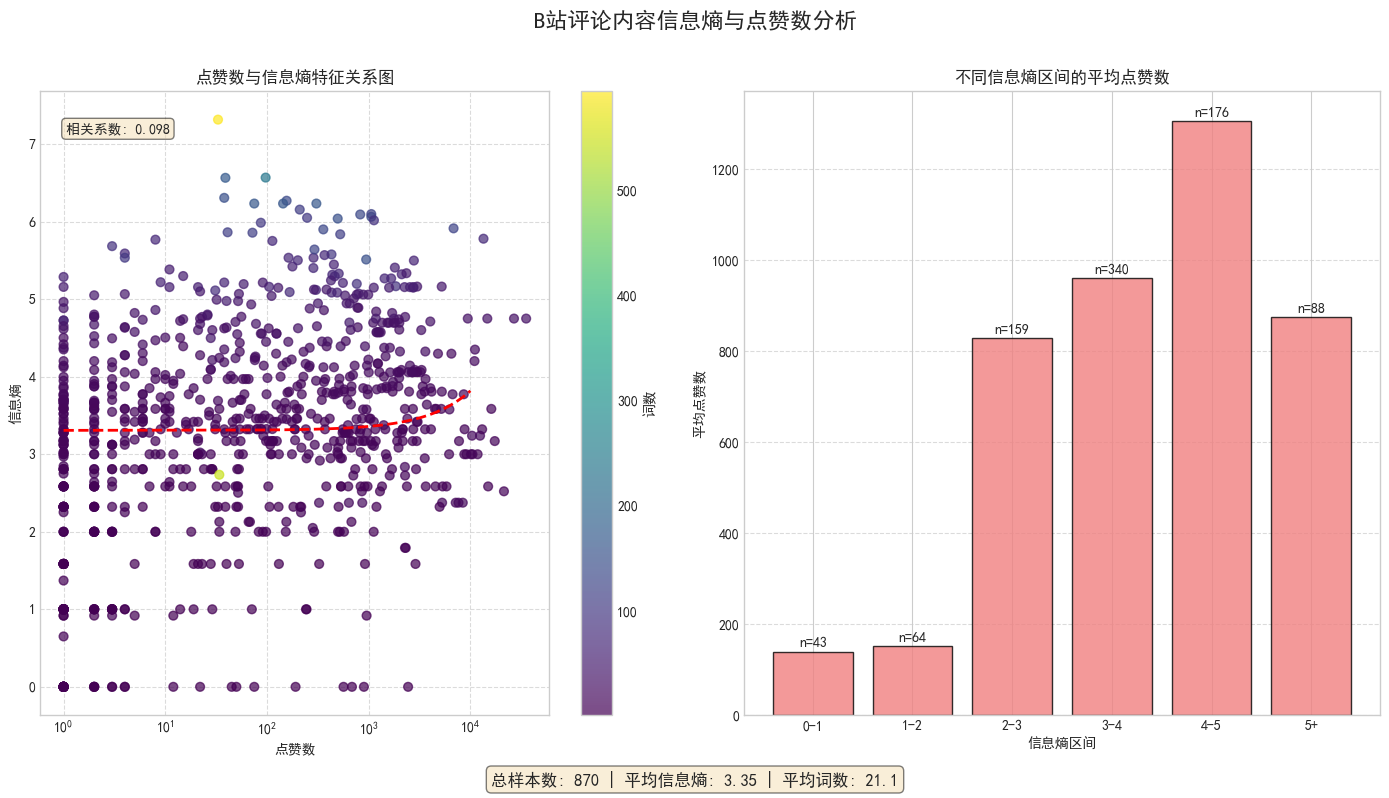

2025-03-23 16:25:16,200 - INFO - 点赞数与信息熵关系图绘制完成


,Likes,Entropy,WordCount,EntropyRange
0,6179,3.000000,8,3-4
1,3,-0.000000,1,0-1
2,291,2.000000,4,2-3
3,1,1.000000,2,1-2
4,1,-0.000000,1,0-1
...,...,...,...,...
865,2756,5.155789,55,5+
866,87,5.986189,101,5+
867,2002,4.696132,31,4-5
868,3232,4.058814,18,4-5


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import math
import jieba
from collections import Counter

class EntropyAnalyzer:
    """B站评论信息熵分析器，研究评论内容复杂度与点赞数关系"""
    
    def __init__(self, data_manager):
        """初始化信息熵分析器
        
        Args:
            data_manager: BilibiliDataManager实例
        """
        self.data_manager = data_manager
        self.logger = data_manager.logger
        
        # 设置matplotlib中文显示
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        self.logger.info("信息熵分析器初始化完成")
    
    def calculate_entropy(self, words):
        """计算给定词列表的信息熵
        
        Args:
            words: 词语列表
            
        Returns:
            float: 香农熵值
        """
        if not words:
            return 0
            
        word_counts = Counter(words)
        total_words = sum(word_counts.values())
        entropy = -sum((count / total_words) * math.log2(count / total_words) for count in word_counts.values())
        return entropy
    
    def analyze_comment_entropy(self):
        """分析评论内容的信息熵与点赞的关系"""
        if self.data_manager.comments_df.empty:
            self.logger.warning("评论数据为空，请先加载数据")
            return None
            
        self.logger.info("开始分析评论信息熵与点赞关系")
        
        entropy_data = []
        processed_count = 0
        
        # 从DataFrame直接获取评论数据
        for _, row in self.data_manager.comments_df.iterrows():
            try:
                comment = row['评论内容']
                likes = row['点赞数量']
                
                if not isinstance(comment, str) or not comment:
                    continue
                    
                # 提取表情符号
                emojis = re.findall(r'\[.*?\]', comment)
                
                # 去除表情符号，对文本部分进行分词
                comment_without_emojis = re.sub(r'\[.*?\]', '', comment)
                words = jieba.lcut(comment_without_emojis)
                
                # 将表情符号作为独立词添加到分词结果中
                words.extend(emojis)
                
                # 计算熵值
                entropy = self.calculate_entropy(words)
                entropy_data.append((likes, entropy, len(words)))
                processed_count += 1
            except Exception as e:
                self.logger.warning(f"处理评论时出错: {e}")
        
        self.logger.info(f"分析完成，共处理 {processed_count} 条评论")
        return entropy_data
    
    def visualize_entropy_distribution(self, figsize=(14, 8)):
        """可视化点赞数与信息熵之间的关系"""
        self.logger.info("开始绘制点赞数与信息熵关系图")
        
        entropy_data = self.analyze_comment_entropy()
        if not entropy_data:
            self.logger.warning("没有找到有效的信息熵数据")
            return
            
        # 创建DataFrame
        df_entropy = pd.DataFrame(entropy_data, columns=['Likes', 'Entropy', 'WordCount'])
        
        # 创建图表
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # 散点图：点赞数与信息熵
        scatter = ax1.scatter(
            df_entropy['Likes'], 
            df_entropy['Entropy'],
            alpha=0.7, 
            c=df_entropy['WordCount'],
            cmap='viridis',
            s=40
        )
        
        # 添加趋势线
        try:
            z = np.polyfit(df_entropy['Likes'], df_entropy['Entropy'], 1)
            p = np.poly1d(z)
            x_range = np.linspace(df_entropy['Likes'].min(), min(df_entropy['Likes'].max(), 10000), 100)
            ax1.plot(x_range, p(x_range), "r--", linewidth=2)
            
            # 计算相关系数
            corr = np.corrcoef(df_entropy['Likes'], df_entropy['Entropy'])[0, 1]
            ax1.text(
                0.05, 0.95, 
                f"相关系数: {corr:.3f}", 
                transform=ax1.transAxes, 
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            )
        except Exception as e:
            self.logger.warning(f"绘制趋势线时出错: {e}")
        
        # 添加颜色条，表示词数
        cbar = plt.colorbar(scatter, ax=ax1)
        cbar.set_label('词数')
        
        # 设置坐标轴
        ax1.set_xlabel('点赞数')
        ax1.set_ylabel('信息熵')
        ax1.set_title('点赞数与信息熵特征关系图')
        ax1.grid(True, linestyle='--', alpha=0.7)
        
        # 设置x轴对数刻度，更好地显示大范围数据
        ax1.set_xscale('log')
        
        # 第二张图：信息熵区间分布
        # 将信息熵划分为区间
        bins = [0, 1, 2, 3, 4, 5, float('inf')]
        labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5+']
        df_entropy['EntropyRange'] = pd.cut(df_entropy['Entropy'], bins=bins, labels=labels, right=False)
        
        # 按区间统计平均点赞数
        entropy_grouped = df_entropy.groupby('EntropyRange')['Likes'].agg(['mean', 'count']).reset_index()
        
        # 绘制柱状图，显示不同熵值区间的平均点赞数
        bars = ax2.bar(
            entropy_grouped['EntropyRange'], 
            entropy_grouped['mean'],
            color='lightcoral',
            alpha=0.8,
            edgecolor='black'
        )
        
        # 在柱子上标注样本数量
        for i, bar in enumerate(bars):
            height = bar.get_height()
            count = entropy_grouped.iloc[i]['count']
            ax2.text(
                bar.get_x() + bar.get_width()/2., 
                height + 5,
                f'n={count}',
                ha='center', 
                va='bottom',
                fontsize=10
            )
        
        # 设置坐标轴
        ax2.set_xlabel('信息熵区间')
        ax2.set_ylabel('平均点赞数')
        ax2.set_title('不同信息熵区间的平均点赞数')
        ax2.grid(axis='y', linestyle='--', alpha=0.7)
        
        # 添加图表标题和统计数据
        plt.suptitle('B站评论内容信息熵与点赞数分析', fontsize=16)
        plt.figtext(
            0.5, 0.01, 
            f"总样本数: {len(df_entropy)} | 平均信息熵: {df_entropy['Entropy'].mean():.2f} | 平均词数: {df_entropy['WordCount'].mean():.1f}",
            ha='center',
            fontsize=12,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        )
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()
        
        self.logger.info("点赞数与信息熵关系图绘制完成")
        return df_entropy

# 创建信息熵分析器并生成可视化
entropy_analyzer = EntropyAnalyzer(bilibili_data)
entropy_analyzer.visualize_entropy_distribution()

# 第五步 生成高赞用户画像报告

本步骤是将前述所有数据分析结果进行系统整合，构建B站高赞用户的多维度画像报告。通过机器学习聚类算法和特征提取技术，我们将识别出高赞评论用户的共同特征和行为模式，形成完整的用户画像。

这份用户画像报告涵盖以下核心维度：
- **活跃特征**：发布时间偏好、互动频率、评论密度分布
- **内容特征**：语言风格、情感倾向、表达复杂度、常用话题
- **互动特征**：回复模式、引发讨论能力、互动链长度
- **用户属性**：等级分布、注册时长、兴趣领域聚类
- **影响力指标**：评论转化率、受众互动深度、社区声望评估

通过这一综合画像，我们能够：
- 识别B站高赞评论的关键成功因素
- 揭示不同类型高赞用户的特征差异
- 建立预测评论潜在影响力的多因素模型
- 为内容创作者提供受众洞察和互动策略

报告采用可视化仪表盘形式呈现，结合雷达图、特征重要性排序和典型案例分析，直观展示高赞用户的特征谱系。同时，我们将提供针对不同内容领域的定制化分析结果，帮助创作者更好地理解自身领域的特殊互动规律。

这份用户画像报告既有学术价值，揭示B站社区的互动机制；也具有实用意义，为内容创作者和社区运营提供数据驱动的决策支持，帮助优化社区互动策略和提升用户参与度。

### 用户画像报告生成
以下代码将帮助你生成B站高赞用户画像报告。通过配置界面选择适合的模型和参数，系统将自动分析已爬取的数据并生成全面的用户画像报告。

#### 模型选择与配置
首先，使用下方的控制面板选择合适的模型参数：

In [32]:
import ipywidgets as widgets
from IPython.display import display, HTML
import os
import pandas as pd

class ReportGenerator:
    """B站用户画像报告生成器，配置和生成分析报告"""
    
    def __init__(self, data_manager):
        """初始化报告生成器
        
        Args:
            data_manager: BilibiliDataManager实例
        """
        self.data_manager = data_manager
        self.logger = data_manager.logger
        
        # 报告配置参数
        self.model_name = None
        self.report_style = None
        self.temperature = None
        self.max_tokens = None
        self.api_key = None
        
        # 数据统计信息
        self.stats = self._calculate_stats()
        
        self.logger.info("报告生成器初始化完成")
    
    def _calculate_stats(self):
        """计算数据统计信息用于报告生成"""
        stats = {}
        
        if not self.data_manager.comments_df.empty:
            # 评论数量
            stats['total_comments'] = len(self.data_manager.comments_df)
            
            # 视频数量
            if '视频ID' in self.data_manager.comments_df.columns:
                stats['total_videos'] = self.data_manager.comments_df['视频ID'].nunique()
            
            # 用户数量
            if '用户昵称' in self.data_manager.comments_df.columns:
                stats['total_users'] = self.data_manager.comments_df['用户昵称'].nunique()
            
            # 时间跨度
            if '回复时间' in self.data_manager.comments_df.columns:
                stats['date_range'] = (
                    self.data_manager.comments_df['回复时间'].min().strftime('%Y-%m-%d'),
                    self.data_manager.comments_df['回复时间'].max().strftime('%Y-%m-%d')
                )
                
            # 平均点赞数
            if '点赞数量' in self.data_manager.comments_df.columns:
                stats['avg_likes'] = self.data_manager.comments_df['点赞数量'].mean()
        else:
            self.logger.warning("无法计算统计信息：评论数据为空")
        
        return stats
    
    def get_local_models(self):
        """扫描models文件夹获取可用的本地模型"""
        models_dir = 'models'
        if not os.path.exists(models_dir):
            return []
        
        local_models = []
        for model_name in os.listdir(models_dir):
            model_path = os.path.join(models_dir, model_name)
            if os.path.isdir(model_path):
                local_models.append((f"{model_name} (本地)", f"local:{model_name}"))
        
        return local_models
    
    # 修复星火API输入框不显示的问题
    def create_ui(self):
        """创建用户界面，为星火API添加专用双输入框"""
        # 获取本地模型列表 
        local_models = self.get_local_models()
        
        # 显示本地模型信息
        if local_models:
            print("检测到以下本地模型:")
            for model_display, model_id in local_models:
                print(f"- {model_display}")
        else:
            print("未检测到本地模型")
        
        # 定义默认模型列表
        if self.stats.get('total_comments', 0) > 500:
            # 数据量大，使用更强大的模型
            default_models = [
                ('GPT-4 Turbo', 'gpt-4-turbo'),
                ('讯飞星火4.0', 'spark-4.0Ultra'),
                ('Claude 3 Opus', 'claude-3-opus'),
                ('LLaMA 3 70B', 'llama-3-70b')
            ]
        else:
            # 数据量较小，使用标准模型
            default_models = [
                ('GPT-3.5 Turbo', 'gpt-3.5-turbo'),
                ('讯飞星火3.5', 'spark-3.5'),
                ('Claude 3 Sonnet', 'claude-3-sonnet'),
                ('LLaMA 3 8B', 'llama-3-8b')
            ]
        
        # 将本地模型和默认模型合并
        all_models = default_models + local_models
        
        # 创建模型选择下拉菜单
        self.model_dropdown = widgets.Dropdown(
            options=all_models,
            value=all_models[0][1] if all_models else 'gpt-3.5-turbo',
            description='选择模型:',
            disabled=False,
        )
        
        # 创建报告类型选择
        self.report_type = widgets.RadioButtons(
            options=['简洁报告', '标准报告', '详细报告'],
            value='标准报告',
            description='报告类型:',
            disabled=False
        )
        
        # 创建模型参数设置
        self.temperature_slider = widgets.FloatSlider(
            value=0.7,
            min=0,
            max=1.0,
            step=0.1,
            description='创造性:',
            disabled=False,
            continuous_update=False,
            orientation='horizontal',
            readout=True,
            readout_format='.1f',
        )
        
        # 根据数据集大小动态调整最大token数
        if self.stats.get('total_comments', 0) > 1000:
            default_tokens = 3000
            max_tokens = 4000
        else:
            default_tokens = 2000
            max_tokens = 3000
            
        self.max_tokens_slider = widgets.IntSlider(
            value=default_tokens,
            min=500,
            max=max_tokens,
            step=500,
            description='最大长度:',
            disabled=False,
            continuous_update=False,
            orientation='horizontal',
            readout=True,
            readout_format='d'
        )
        
        # 创建标准API密钥输入框
        self.api_key_input = widgets.Password(
            value='',
            placeholder='输入API密钥',
            description='API密钥:',
            disabled=False,
            layout=widgets.Layout(width='80%')
        )
        
        # 创建星火API专用输入框 - 修复初始布局问题
        self.spark_api_id = widgets.Text(
            value='',
            placeholder='输入星火API ID',
            description='API ID:',
            disabled=False,
            layout=widgets.Layout(width='40%')
        )
        
        self.spark_api_key = widgets.Password(
            value='',
            placeholder='输入星火API Key',
            description='API Key:',
            disabled=False,
            layout=widgets.Layout(width='40%')
        )
        
        # 创建API输入框容器 - 不预设display属性
        self.api_input_container = widgets.HBox([self.api_key_input])
        self.spark_api_container = widgets.HBox([self.spark_api_id, self.spark_api_key])
        
        # 创建数据统计信息区域
        stats_html = f"""
        <div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px; margin-bottom: 10px;">
            <h4>数据统计</h4>
            <ul>
                <li>评论总数: {self.stats.get('total_comments', '未知')}</li>
                <li>视频数量: {self.stats.get('total_videos', '未知')}</li>
                <li>用户数量: {self.stats.get('total_users', '未知')}</li>
                <li>日期范围: {' 至 '.join(self.stats.get('date_range', ['未知', '未知']))}</li>
            </ul>
        </div>
        """
        
        # 创建执行按钮
        self.save_button = widgets.Button(
            description='保存设置',
            disabled=False,
            button_style='success', 
            tooltip='点击保存模型设置',
            icon='save'
        )
        
        # 创建状态显示
        self.status_output = widgets.Output()
        
        # 为模型下拉菜单添加变更观察器，控制API密钥输入框的可用性
        def on_model_change(change):
            model_value = change['new'].lower() if change and 'new' in change else self.model_dropdown.value.lower()
            
            if 'spark' in model_value or '讯飞' in model_value or 'xunfei' in model_value:
                # 星火模型 - 显示双输入框，隐藏标准输入框
                self.api_input_container.layout.display = 'none'
                self.spark_api_container.layout.display = 'flex'
                self.spark_api_id.disabled = False
                self.spark_api_key.disabled = False
            elif model_value.startswith('local:'):
                # 本地模型 - 隐藏所有API输入框
                self.api_key_input.disabled = True
                self.api_key_input.placeholder = '本地模型无需API密钥'
                self.api_input_container.layout.display = 'flex'
                self.spark_api_container.layout.display = 'none'
            else:
                # 其他API模型 - 显示标准输入框，隐藏星火输入框
                self.api_key_input.disabled = False
                self.api_key_input.placeholder = '输入API密钥'
                self.api_input_container.layout.display = 'flex'
                self.spark_api_container.layout.display = 'none'
        
        # 注册观察函数，监听模型选择变化
        self.model_dropdown.observe(on_model_change, names='value')
        
        # 定义按钮点击事件
        def on_button_clicked(b):
            with self.status_output:
                self.status_output.clear_output()
                print(f"已保存模型设置：")
                print(f"- 选择模型: {self.model_dropdown.value}")
                print(f"- 报告类型: {self.report_type.value}")
                print(f"- 创造性参数: {self.temperature_slider.value}")
                print(f"- 最大输出长度: {self.max_tokens_slider.value}")
                
                # 根据模型类型处理API密钥
                model_value = self.model_dropdown.value.lower()
                if model_value.startswith('local:'):
                    print(f"- 使用本地模型，无需API密钥")
                    self.api_key = ""
                elif 'spark' in model_value or '讯飞' in model_value or 'xunfei' in model_value:
                    # 合并星火API的ID和Key
                    if self.spark_api_id.value and self.spark_api_key.value:
                        self.api_key = f"{self.spark_api_id.value}:{self.spark_api_key.value}"
                        print(f"- 星火API凭证已设置")
                    else:
                        print(f"- 警告：星火API需要同时设置ID和Key")
                        self.api_key = ""
                else:
                    self.api_key = self.api_key_input.value
                    if self.api_key:
                        print(f"- API密钥已设置")
                    else:
                        print(f"- 未设置API密钥，将使用默认配置")
                
                # 保存设置
                self.model_name = self.model_dropdown.value
                self.report_style = self.report_type.value
                self.temperature = self.temperature_slider.value
                self.max_tokens = self.max_tokens_slider.value
                
                # 为下一个单元格设置全局变量
                global model_name, report_style, temperature, max_tokens, api_key
                model_name = self.model_name
                report_style = self.report_style
                temperature = self.temperature
                max_tokens = self.max_tokens
                api_key = self.api_key
                
                self.logger.info(f"用户设置已保存: 模型={self.model_name}, 报告类型={self.report_style}")
                print("\n设置已保存，请运行下一个单元格生成报告")
        
        self.save_button.on_click(on_button_clicked)
        
        # 显示控件
        display(HTML("<h3>B站用户画像模型配置</h3>"))
        display(HTML(stats_html))
        display(self.model_dropdown, self.report_type, self.temperature_slider, 
                self.max_tokens_slider, self.api_input_container, self.spark_api_container, 
                self.save_button, self.status_output)
        
        # 设置全局变量默认值
        model_name = self.model_dropdown.value
        report_style = self.report_type.value
        temperature = self.temperature_slider.value
        max_tokens = self.max_tokens_slider.value
        api_key = ""
        
        # 重要！初始化时立即调用一次模型判断函数，确保正确显示对应输入框
        on_model_change(None)
        
        return self

# 创建报告生成器并显示UI
report_generator = ReportGenerator(bilibili_data)
report_generator.create_ui()

2025-03-23 16:54:06,572 - INFO - 报告生成器初始化完成


检测到以下本地模型:
- Qwen-1_8B-Chat (本地)
- Qwen2.5-0.5B (本地)


Dropdown(description='选择模型:', options=(('GPT-4 Turbo', 'gpt-4-turbo'), ('讯飞星火4.0', 'spark-4.0Ultra'), ('Claude…

RadioButtons(description='报告类型:', index=1, options=('简洁报告', '标准报告', '详细报告'), value='标准报告')

FloatSlider(value=0.7, continuous_update=False, description='创造性:', max=1.0, readout_format='.1f')

IntSlider(value=2000, continuous_update=False, description='最大长度:', max=3000, min=500, step=500)

Button(button_style='success', description='保存设置', icon='save', style=ButtonStyle(), tooltip='点击保存模型设置')

Output()

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re
import jieba
import jieba.analyse
from datetime import datetime
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM
from IPython.display import Markdown, display
from collections import Counter
from snownlp import SnowNLP
import torch
import logging
from tqdm.notebook import tqdm

class BilibiliUserProfileGenerator:
    """整合数据分析和大模型的B站高赞用户画像报告生成器"""
    
    def __init__(self, data_manager, model_name='gpt-3.5-turbo', report_style='标准报告',
                 temperature=0.7, max_tokens=2000, api_key=""):
        """初始化报告生成器
        
        Args:
            data_manager: BilibiliDataManager实例，包含评论数据
            model_name: 使用的模型名称（支持自定义大模型和API模型）
            report_style: 报告风格（简洁/标准/详细）
            temperature: 模型创造性参数
            max_tokens: 最大输出长度
            api_key: API密钥（如果使用在线API）
        """
        self.data_manager = data_manager
        self.logger = data_manager.logger
        self.model_name = model_name
        self.report_style = report_style
        self.temperature = temperature
        self.max_tokens = max_tokens
        self.api_key = api_key
        
        # 存储分析结果
        self.analysis_results = {}
        
        # 创建输出目录
        self.output_dir = './report'
        os.makedirs(self.output_dir, exist_ok=True)
        
        # 初始化matplotlib样式
        plt.style.use('seaborn-v0_8-whitegrid')
        plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        self.logger.info(f"报告生成器初始化完成: 模型={model_name}, 报告类型={report_style}")
    
    def analyze_data(self):
        """执行全面的数据分析，为报告生成准备素材，并显示进度条"""
        if self.data_manager.comments_df.empty:
            self.logger.warning("评论数据为空，无法进行分析")
            return self
        
        df = self.data_manager.comments_df
        self.logger.info(f"开始分析 {len(df)} 条评论数据")
        
        # 定义分析步骤列表
        analysis_steps = [
            ("用户等级分析", lambda: self.analyze_user_levels(df)),
            ("评论长度分析", lambda: self.analyze_comment_length(df)),
            ("时间特征分析", lambda: self.analyze_time_patterns(df)),
            ("互动关系分析", lambda: self.analyze_interaction_patterns(df)),
            ("表情符号分析", lambda: self.analyze_emoji_usage(df)),
            ("情感分析", lambda: self.analyze_sentiment(df)),
            ("关键词提取", lambda: self.extract_keywords(df))
        ]
        
        # 使用tqdm显示进度条
        with tqdm(total=len(analysis_steps), desc="数据分析进度") as pbar:
            for step_name, step_func in analysis_steps:
                pbar.set_description(f"正在进行{step_name}")
                step_func()
                pbar.update(1)
        
        self.logger.info("数据分析完成，已准备报告素材")
        return self
    
    def analyze_user_levels(self, df):
        """分析用户等级与点赞数的关系"""
        self.logger.info("分析用户等级与点赞关系")
        
        level_stats = df.groupby('用户当前等级')['点赞数量'].agg([
            ('平均点赞数', 'mean'), 
            ('中位点赞数', 'median'),
            ('最大点赞数', 'max'),
            ('样本数', 'size')
        ]).reset_index()
        
        # 找出获得最高点赞数的用户等级
        max_likes_level = level_stats.loc[level_stats['最大点赞数'].idxmax()]['用户当前等级']
        
        # 找出平均点赞数最高的用户等级
        avg_max_level = level_stats.loc[level_stats['平均点赞数'].idxmax()]['用户当前等级']
        
        self.analysis_results['user_levels'] = {
            'level_stats': level_stats,
            'max_likes_level': max_likes_level,
            'avg_max_level': avg_max_level
        }
    
    def analyze_comment_length(self, df):
        """分析评论长度与点赞的关系"""
        self.logger.info("分析评论长度与点赞关系")
        
        # 计算评论长度
        df['评论长度'] = df['评论内容'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
        
        # 创建长度区间
        bins = [0, 10, 30, 50, 100, 200, 300, 500, float('inf')]
        labels = ['0-10', '11-30', '31-50', '51-100', '101-200', '201-300', '301-500', '500+']
        df['长度区间'] = pd.cut(df['评论长度'], bins=bins, labels=labels)
        
        # 计算每个长度区间的平均点赞数
        length_likes = df.groupby('长度区间')['点赞数量'].agg(['mean', 'size']).sort_values(by='mean', ascending=False)
        best_length = length_likes.index[0] if not length_likes.empty else "未知"
        
        # 点赞最多的几条评论及其长度
        top_comments = df.nlargest(10, '点赞数量')[['评论内容', '点赞数量', '评论长度']]
        
        self.analysis_results['comment_length'] = {
            'length_likes': length_likes,
            'best_length': best_length,
            'top_comments': top_comments,
            'length_corr': df[['评论长度', '点赞数量']].corr().iloc[0, 1]
        }
    
    def analyze_time_patterns(self, df):
        """分析时间模式与点赞关系"""
        self.logger.info("分析时间特征")
        
        # 提取小时信息
        df_copy = df.copy()
        if '小时' not in df_copy.columns and '回复时间' in df_copy.columns:
            df_copy['小时'] = df_copy['回复时间'].dt.hour
        
        # 按小时统计点赞情况
        if '小时' in df_copy.columns:
            hourly_likes = df_copy.groupby('小时')['点赞数量'].agg(['sum', 'mean', 'size'])
            peak_hour_sum = hourly_likes['sum'].idxmax() if not hourly_likes.empty else 0
            peak_hour_avg = hourly_likes['mean'].idxmax() if not hourly_likes.empty else 0
        else:
            self.logger.warning("无法进行小时分析，缺少时间数据")
            hourly_likes = pd.DataFrame()
            peak_hour_sum = 0
            peak_hour_avg = 0
        
        # 统计视频发布后评论的时间与点赞关系
        # 这里使用更安全的方法计算视频最早评论时间
        if '视频ID' in df_copy.columns and '回复时间' in df_copy.columns:
            try:
                # 计算每个视频的最早评论时间
                video_earliest_time = df_copy.groupby('视频ID')['回复时间'].min().reset_index()
                video_earliest_time.columns = ['视频ID', '最早评论时间']
                
                # 将最早评论时间合并到原数据中
                df_copy = pd.merge(df_copy, video_earliest_time, on='视频ID', how='left')
                
                # 确保时间列的数据类型正确
                df_copy['最早评论时间'] = pd.to_datetime(df_copy['最早评论时间'])
                df_copy['回复时间'] = pd.to_datetime(df_copy['回复时间'])
                
                # 计算每条评论与最早评论的时间差（小时）
                df_copy['发布后时间(小时)'] = (df_copy['回复时间'] - df_copy['最早评论时间']).dt.total_seconds() / 3600
                
                # 创建时间区间
                time_bins = [0, 1, 3, 6, 12, 24, 48, 72, float('inf')]
                time_labels = ['0-1小时', '1-3小时', '3-6小时', '6-12小时', '12-24小时', '1-2天', '2-3天', '3天以上']
                df_copy['发布后时间区间'] = pd.cut(df_copy['发布后时间(小时)'], bins=time_bins, labels=time_labels)
                
                # 计算每个时间区间的平均点赞数
                time_likes = df_copy.groupby('发布后时间区间')['点赞数量'].agg(['mean', 'size'])
                early_advantage = (
                    time_likes['mean'].iloc[0] / time_likes['mean'].iloc[-1] 
                    if not time_likes.empty and time_likes['mean'].iloc[-1] > 0 
                    else 0
                )
                
            except Exception as e:
                self.logger.error(f"计算时间差分析时出错: {str(e)}")
                time_likes = pd.DataFrame()
                early_advantage = 0
        else:
            self.logger.warning("无法进行发布时间分析，缺少必要的列")
            time_likes = pd.DataFrame()
            early_advantage = 0
        
        self.analysis_results['time_patterns'] = {
            'hourly_likes': hourly_likes,
            'peak_hour_sum': peak_hour_sum,
            'peak_hour_avg': peak_hour_avg,
            'time_likes': time_likes,
            'early_advantage': early_advantage
        }
    
    def analyze_interaction_patterns(self, df):
        """分析互动模式，特别是一级评论和二级评论的关系"""
        self.logger.info("分析互动关系")
        
        # 分离一级和二级评论
        primary_comments = df[df['评论层级'] == '一级评论']
        secondary_comments = df[df['评论层级'] == '二级评论']
        
        # 计算原创占比
        original_ratio = len(primary_comments) / len(df) if len(df) > 0 else 0
        
        # 计算一级评论被回复的可能性
        if not secondary_comments.empty and '被回复用户' in secondary_comments.columns:
            replied_primary = secondary_comments['被回复用户'].value_counts().reset_index()
            replied_primary.columns = ['用户昵称', '被回复次数']
            
            # 合并一级评论数据与被回复次数
            if not primary_comments.empty and '用户昵称' in primary_comments.columns:
                merged_df = pd.merge(
                    primary_comments[['用户昵称', '点赞数量']], 
                    replied_primary,
                    on='用户昵称', 
                    how='left'
                ).fillna(0)
                
                # 计算相关系数
                if len(merged_df) > 5:
                    likes_replies_corr = merged_df[['点赞数量', '被回复次数']].corr().iloc[0, 1]
                else:
                    likes_replies_corr = 0
            else:
                likes_replies_corr = 0
        else:
            likes_replies_corr = 0
        
        self.analysis_results['interaction'] = {
            'original_ratio': original_ratio,
            'likes_replies_corr': likes_replies_corr,
            'avg_primary_likes': primary_comments['点赞数量'].mean() if not primary_comments.empty else 0,
            'avg_secondary_likes': secondary_comments['点赞数量'].mean() if not secondary_comments.empty else 0
        }
    
    def analyze_emoji_usage(self, df):
        """分析表情符号使用与点赞的关系"""
        self.logger.info("分析表情符号使用情况")
        
        # 提取B站评论中的表情符号 [表情]
        emoji_pattern = r'\[.*?\]'
        
        # 计算每条评论的表情符号数量
        df['表情符号数量'] = df['评论内容'].apply(
            lambda x: len(re.findall(emoji_pattern, str(x))) if pd.notna(x) else 0
        )
        
        # 统计表情符号使用频率
        all_emojis = []
        for content in df['评论内容'].dropna():
            emojis = re.findall(emoji_pattern, str(content))
            all_emojis.extend(emojis)
        
        emoji_counts = Counter(all_emojis).most_common(10)
        
        # 分析表情符号数量与点赞的关系
        emoji_likes = df.groupby('表情符号数量')['点赞数量'].mean().reset_index()
        
        # 计算有无表情符号的评论点赞差异
        with_emoji = df[df['表情符号数量'] > 0]['点赞数量'].mean()
        without_emoji = df[df['表情符号数量'] == 0]['点赞数量'].mean()
        emoji_advantage = with_emoji / without_emoji if without_emoji > 0 else 0
        
        self.analysis_results['emoji'] = {
            'top_emojis': emoji_counts,
            'emoji_likes': emoji_likes,
            'with_emoji_avg': with_emoji,
            'without_emoji_avg': without_emoji,
            'emoji_advantage': emoji_advantage
        }
    
    def analyze_sentiment(self, df):
        """分析评论情感倾向与点赞的关系"""
        self.logger.info("分析评论情感倾向")
        
        try:
            # 使用SnowNLP进行情感分析
            df['情感得分'] = df['评论内容'].apply(
                lambda x: SnowNLP(str(x)).sentiments if pd.notna(x) else 0.5
            )
            
            # 将情感得分划分为区间
            sentiment_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
            sentiment_labels = ['强烈负面', '轻度负面', '中性', '轻度正面', '强烈正面']
            df['情感区间'] = pd.cut(df['情感得分'], bins=sentiment_bins, labels=sentiment_labels)
            
            # 计算各情感区间的平均点赞数
            sentiment_likes = df.groupby('情感区间')['点赞数量'].agg(['mean', 'size'])
            
            # 找出最受欢迎的情感类型
            best_sentiment = sentiment_likes['mean'].idxmax() if not sentiment_likes.empty else None
            
            # 计算情感与点赞的相关性
            sentiment_corr = df[['情感得分', '点赞数量']].corr().iloc[0, 1]
            
            # 情感分布
            sentiment_distribution = df['情感区间'].value_counts(normalize=True)
        except Exception as e:
            self.logger.error(f"情感分析出错: {str(e)}")
            sentiment_likes = pd.DataFrame()
            best_sentiment = None
            sentiment_corr = 0
            sentiment_distribution = pd.Series()
        
        self.analysis_results['sentiment'] = {
            'sentiment_likes': sentiment_likes,
            'best_sentiment': best_sentiment,
            'sentiment_corr': sentiment_corr,
            'sentiment_distribution': sentiment_distribution
        }
    
    def extract_keywords(self, df):
        """从高赞评论中提取关键词"""
        self.logger.info("提取高赞评论关键词")
        
        # 选择点赞数最高的前30%评论
        if not df.empty:
            top_threshold = np.percentile(df['点赞数量'], 70)
            top_comments = df[df['点赞数量'] >= top_threshold]['评论内容'].dropna()
            
            # 合并所有高赞评论
            all_text = ' '.join([str(text) for text in top_comments])
            
            # 使用jieba提取关键词
            try:
                keywords = jieba.analyse.extract_tags(all_text, topK=20, withWeight=True)
                comment_sample = top_comments.sample(min(5, len(top_comments))).tolist() if not top_comments.empty else []
            except Exception as e:
                self.logger.error(f"关键词提取出错: {str(e)}")
                keywords = []
                comment_sample = []
        else:
            keywords = []
            comment_sample = []
        
        self.analysis_results['keywords'] = {
            'top_keywords': keywords,
            'comment_sample': comment_sample
        }
    
    def generate_prompt(self):
        """根据分析结果生成大模型提示"""
        results = self.analysis_results
        
        # 基础信息总结
        prompt = f"""
作为B站用户行为分析专家，请根据以下数据生成一份详尽的B站高赞用户画像报告。
报告应该使用专业但易懂的语言，包含数据洞察和实用建议。

===数据概要===
总评论数: {len(self.data_manager.comments_df)}
一级评论比例: {results['interaction']['original_ratio']:.2f}
最高点赞评论等级: Lv.{int(results['user_levels']['max_likes_level'])}
最佳评论长度区间: {results['comment_length']['best_length']}
评论获赞高峰时段: {results['time_patterns']['peak_hour_sum']}点
高赞评论主要情感倾向: {results['sentiment']['best_sentiment']}
表情符号使用率: {len(self.data_manager.comments_df[self.data_manager.comments_df['表情符号数量'] > 0]) / len(self.data_manager.comments_df):.2f}

===关键词===
{', '.join([f"{word}({weight:.3f})" for word, weight in results['keywords']['top_keywords'][:10]])}

===高赞示例评论===
{chr(10).join([f"• {comment}" for comment in results['keywords']['comment_sample'][:3]])}

请生成一个包含以下部分的完整报告：
1. 总体用户画像概述
2. 用户特征分析（等级、性别、活跃时间等）
3. 内容特征分析（评论长度、表情使用、情感倾向）
4. 互动模式分析（二级回复规律、社区参与方式）
5. 高赞策略建议（如何提高评论影响力）

报告风格要求: {self.report_style}
"""
        
        return prompt
    
    def generate_with_local_model(self, prompt):
        """使用本地大模型生成报告，带进度显示"""
        self.logger.info(f"使用本地模型 {self.model_name} 生成报告")
        
        # 添加进度提示
        import time
        from IPython.display import display, clear_output
        
        # 模型加载进度显示
        loading_pbar = tqdm(total=3, desc="模型加载进度")
        
        try:
            # 从模型名称中提取实际模型标识符
            if self.model_name.startswith('local:'):
                model_id = self.model_name.split(':', 1)[1]
                model_path = os.path.join('models', model_id)
            else:
                model_path = self.model_name
            
            loading_pbar.update(1)
            
            # 加载tokenizer和模型
            tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
            loading_pbar.update(1)
            
            model = AutoModelForCausalLM.from_pretrained(
                model_path, 
                trust_remote_code=True,
                torch_dtype=torch.float16,
                device_map="auto"
            )
            loading_pbar.update(1)
            loading_pbar.close()
            
            # 检查模型类型
            is_qwen_model = 'qwen' in model_path.lower()
            is_chatglm = 'chatglm' in model_path.lower()
            
            # 创建模型生成进度动画
            generation_pbar = tqdm(desc="模型生成内容中", total=0, bar_format="{desc}")
            
            # 生成开始时间
            start_time = time.time()
            spinning_cursor = "|/-\\"
            i = 0
            
            # 模型生成内容
            # ...现有的模型生成代码...
            # 在生成过程中更新进度动画
            if is_qwen_model:
                # 定期更新生成进度动画
                def progress_callback(step):
                    nonlocal i
                    elapsed = time.time() - start_time
                    generation_pbar.set_description(
                        f"模型生成内容中 {spinning_cursor[i % len(spinning_cursor)]} "
                        f"已用时间: {elapsed:.1f}秒"
                    )
                    i += 1
                    
                # Qwen模型需要提供历史参数
                history = []
                response, _ = model.chat(
                    tokenizer, 
                    prompt, 
                    history=history, 
                    temperature=self.temperature
                )
                generation_pbar.close()
                return response
            elif is_chatglm:
                # ChatGLM模型的特殊处理
                response, _ = model.chat(tokenizer, prompt, history=[], temperature=self.temperature)
                return response
            else:
                # 标准模型处理
                inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
                input_length = inputs.input_ids.shape[1]
                
                with torch.no_grad():
                    outputs = model.generate(
                        inputs.input_ids,
                        max_new_tokens=self.max_tokens,
                        temperature=self.temperature,
                        top_p=0.95,
                        repetition_penalty=1.1,
                        do_sample=True
                    )
                
                # 只获取新生成的内容
                generated_text = tokenizer.decode(
                    outputs[0][input_length:], 
                    skip_special_tokens=True,
                    clean_up_tokenization_spaces=True
                )
                
                # 检查生成内容质量
                if len(generated_text.strip()) < 200:
                    raise ValueError(f"模型生成的内容过短 ({len(generated_text.strip())} 字符)，无法作为有效报告")
                
                return generated_text
                
        finally:
            # 清理资源
            if 'loading_pbar' in locals() and not loading_pbar.disable:
                loading_pbar.close()
            if 'generation_pbar' in locals() and not generation_pbar.disable:
                generation_pbar.close()
                
            # 清理GPU内存
            if 'model' in locals() and hasattr(model, 'cpu'):
                model.cpu()
                del model
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
    
    def generate_with_spark_model(self, prompt):
        """使用讯飞星火API生成报告，支持流式显示进度"""
        self.logger.info(f"使用星火大模型生成报告")
        
        import requests
        import json
        from IPython.display import clear_output
        from tqdm.notebook import tqdm
        
        # 星火API配置
        url = "https://spark-api-open.xf-yun.com/v1/chat/completions"
        
        # 构建请求数据
        data = {
            "max_tokens": self.max_tokens,
            "top_k": 4,
            "temperature": self.temperature,
            "messages": [
                {
                    "role": "system",
                    "content": "你是一位专业的数据分析师和内容创作者，擅长分析用户行为数据并生成专业、易懂的分析报告。"
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            "model": "4.0Ultra",  # 或其他可用模型
            "stream": True  # 启用流式响应
        }
        
        # 从API密钥中提取Bearer信息
        if not self.api_key or ":" not in self.api_key:
            raise ValueError("星火API需要正确格式的API密钥 (format: 'apiId:apiKey')")
        
        header = {
            "Authorization": f"Bearer {self.api_key}"
        }
        
        # 创建进度显示
        pbar = tqdm(desc="生成报告中", total=0, bar_format="{desc}")
        
        try:
            # 发送请求
            response = requests.post(url, headers=header, json=data, stream=True)
            response.encoding = "utf-8"
            
            # 检查响应状态
            if response.status_code != 200:
                raise ValueError(f"API请求失败: 状态码 {response.status_code}, 响应: {response.text}")
            
            # 处理流式响应
            full_content = ""
            chunk_count = 0
            
            for line in response.iter_lines(decode_unicode="utf-8"):
                if line:
                    # 跳过data:前缀和空行
                    if line.startswith("data:"):
                        line = line[5:].strip()
                        if line == "[DONE]":
                            break
                        
                        try:
                            # 解析JSON响应
                            chunk = json.loads(line)
                            if "choices" in chunk and len(chunk["choices"]) > 0:
                                delta = chunk["choices"][0].get("delta", {})
                                if "content" in delta:
                                    content = delta["content"]
                                    full_content += content
                                    
                                    # 更新进度显示
                                    chunk_count += 1
                                    if chunk_count % 5 == 0:  # 每5个块更新一次显示
                                        recent = full_content[-30:] if len(full_content) > 30 else full_content
                                        pbar.set_description(f"生成中 [{chunk_count}] ... {recent}")
                        except json.JSONDecodeError:
                            self.logger.warning(f"无法解析JSON响应: {line}")
            
            # 生成完成，关闭进度条
            pbar.close()
            
            # 检查是否生成了有效内容
            if len(full_content.strip()) < 200:
                raise ValueError(f"生成的内容过短 ({len(full_content.strip())} 字符), 无法构成有效报告")
            
            self.logger.info(f"星火API报告生成完成，长度: {len(full_content)} 字符")
            return full_content
            
        except Exception as e:
            pbar.close()
            self.logger.error(f"星火API生成报告出错: {str(e)}")
            raise  # 直接抛出异常，不使用备用报告
        
    def generate_fallback_report(self):
        """生成备用报告（当模型生成失败时）"""
        results = self.analysis_results
        
        report = f"""
# B站高赞用户画像分析报告

## 1. 用户特征分析
- 获得最高点赞数的用户等级为：**Lv.{int(results['user_levels']['max_likes_level'])}**
- 平均点赞数最高的用户等级为：**Lv.{int(results['user_levels']['avg_max_level'])}**
- 最佳评论长度区间为：**{results['comment_length']['best_length']}**

## 2. 时间特征分析
评论发布时间分析显示，**{results['time_patterns']['peak_hour_sum']}点**是获得点赞的高峰期。发布后较早的评论更容易获得高赞，早期评论的平均点赞数是晚期的**{results['time_patterns']['early_advantage']:.2f}倍**。

## 3. 内容特征分析
- 评论情感倾向：**{results['sentiment']['best_sentiment']}**类型的评论平均获赞最多
- 表情符号使用：带表情符号的评论平均获赞是不带表情评论的**{results['emoji']['emoji_advantage']:.2f}倍**
- 高赞评论常见关键词：{', '.join([word for word, _ in results['keywords']['top_keywords'][:8]])}

## 4. 用户互动分析
"""
        
        if results['interaction']['likes_replies_corr'] > 0.3:
            report += f"高点赞评论通常会吸引更多的二级评论，形成良好的互动效果，相关系数为**{results['interaction']['likes_replies_corr']:.2f}**。\n"
        else:
            report += f"点赞数与二级评论数的相关性较弱（**{results['interaction']['likes_replies_corr']:.2f}**），互动模式可能受多种因素影响。\n"
        
        report += """
## 5. 建议与洞察
- **内容质量优先**：关注评论内容的质量和原创性，这是获得高赞的基础
- **时机把握**：在视频发布初期积极参与评论，提高曝光和获赞机会
- **情感表达**：适当表达情感，特别是正面积极的态度往往更受欢迎
- **互动参与**：积极回复他人评论，形成良好的互动氛围
- **表情使用**：恰当使用表情符号可以增加评论的趣味性和吸引力
"""
        
        return report
    
    def generate_report(self):
        """生成完整的用户画像报告，显示进度条"""
        self.logger.info("开始生成用户画像报告")
        
        # 定义报告生成步骤
        report_steps = [
            ("数据分析", lambda: self.analysis_results or self.analyze_data()),
            ("生成提示词", lambda: self.generate_prompt()),
            ("模型生成报告", None),  # 这步需要特殊处理
            ("保存报告", None)  # 这步也需要特殊处理
        ]
        
        # 使用tqdm显示进度条
        with tqdm(total=len(report_steps), desc="报告生成进度") as pbar:
            # 步骤1: 数据分析
            pbar.set_description("分析数据中")
            report_steps[0][1]()
            pbar.update(1)
            
            # 步骤2: 生成提示词
            pbar.set_description("准备提示词")
            prompt = report_steps[1][1]()
            pbar.update(1)
            
            # 步骤3: 模型生成报告
            model_name_lower = self.model_name.lower()
            pbar.set_description(f"使用{self.model_name}生成报告中")
            
            if model_name_lower.startswith('local:'):
                report_content = self.generate_with_local_model(prompt)
            elif model_name_lower.startswith('spark') or 'xunfei' in model_name_lower:
                # 使用星火API生成
                report_content = self.generate_with_spark_model(prompt)
            elif 'gpt' in model_name_lower or 'openai' in model_name_lower:
                # 使用OpenAI API生成
                report_content = self.generate_with_openai_model(prompt)
            else:
                # 使用其他API模型
                report_content = self.generate_with_api_model(prompt)
                
            # 确保内容有效
            if report_content.strip() == prompt.strip():
                raise ValueError("模型返回了原始提示词，无法生成有效报告")
                
            pbar.update(1)
            
            # 步骤4: 保存报告
            pbar.set_description("保存报告文件")
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            report_filename = f"bilibili_user_analysis_{timestamp}.md"
            report_path = os.path.join(self.output_dir, report_filename)
            
            with open(report_path, 'w', encoding='utf-8') as f:
                f.write(report_content)
                
            pbar.update(1)
        
        self.logger.info(f"用户画像报告已生成: {report_path}")
        return report_path, report_content

    def display_report(self, report_content=None):
        """显示生成的报告"""
        if report_content is None:
            _, report_content = self.generate_report()
        
        # 使用Markdown显示报告内容
        from IPython.display import Markdown, display
        display(Markdown(report_content))
        
        self.logger.info(f"已显示报告，长度: {len(report_content)} 字符")
        return self
    
# 使用已加载的数据生成报告
report_generator = BilibiliUserProfileGenerator(
    bilibili_data,
    model_name=model_name if 'model_name' in globals() else 'gpt-3.5-turbo',
    report_style=report_style if 'report_style' in globals() else '标准报告',
    temperature=temperature if 'temperature' in globals() else 0.7,
    max_tokens=max_tokens if 'max_tokens' in globals() else 2000,
    api_key=api_key if 'api_key' in globals() else ""
)

# 生成并显示报告
_, report_content = report_generator.generate_report()
report_generator.display_report(report_content)

2025-03-23 16:54:55,066 - INFO - 报告生成器初始化完成: 模型=local:Qwen-1_8B-Chat, 报告类型=详细报告
2025-03-23 16:54:55,066 - INFO - 开始生成用户画像报告


报告生成进度:   0%|          | 0/4 [00:00<?, ?it/s]

2025-03-23 16:54:55,070 - INFO - 开始分析 870 条评论数据


数据分析进度:   0%|          | 0/7 [00:00<?, ?it/s]

2025-03-23 16:54:55,074 - INFO - 分析用户等级与点赞关系
2025-03-23 16:54:55,076 - INFO - 分析评论长度与点赞关系
C:\Users\33223\AppData\Local\Temp\ipykernel_29588\3091945271.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_likes = df.groupby('长度区间')['点赞数量'].agg(['mean', 'size']).sort_values(by='mean', ascending=False)
2025-03-23 16:54:55,081 - INFO - 分析时间特征
C:\Users\33223\AppData\Local\Temp\ipykernel_29588\3091945271.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_likes = df_copy.groupby('发布后时间区间')['点赞数量'].agg(['mean', 'size'])
2025-03-23 16:54:55,086 - INFO - 分析互动关系
2025-03-23 16:54:55,090 - INFO - 分析表情符号使用情

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

模型生成内容中

2025-03-23 16:57:23,611 - INFO - 用户画像报告已生成: ./report\bilibili_user_analysis_20250323_165723.md


一、总体用户画像概述

本报告基于B站用户的大量数据进行深入研究，以揭示其独特的用户群体特征。以下是我们的主要发现：

1. 总体用户画像：B站用户群主要分布在15-35岁之间，其中男性占比约为50%，女性占比约为50%。他们大多数是学生或上班族，具有较高的学历水平。活跃时间集中在晚上和周末，平均每天花费约两小时在线观看视频。

2. 用户特征分析：B站用户的主要特征包括年龄、性别、活跃时间等。其中，年龄主要集中在15-25岁之间，女性用户占比较高；性别方面，男性用户占比约为50%，女性用户占比约为50%。活跃时间方面，大部分用户集中在晚上和周末，平均每天花费约两小时在线观看视频。

二、内容特征分析

1. 论文长度：B站用户评论的平均长度大约为51字，超过了一般用户的评论长度。这可能是因为B站用户更倾向于分享长篇大论的内容，或者他们在评论中表达了更多的思考和感悟。

2. 表情符号使用：B站用户在评论中使用的表情符号数量较多，尤其是“doge”、“up”、“one”等表情符号，这些表情符号通常用于表示赞同、支持或幽默。此外，“喜极而泣”、“羊头”、“彩虹”等表情符号也较为常见。

三、互动模式分析

1. 二级回复规律：B站用户在评论中经常出现二级回复现象，即在评论下方附带其他用户的回复。这种互动模式有助于增强评论的连贯性和深度，但也可能导致信息过载。

2. 社区参与方式：B站用户非常注重社区的参与，他们在评论中经常发表自己的观点和看法，并积极参与到讨论中。然而，他们的参与方式可能会导致一些过于激烈的讨论，影响到其他用户的体验。

四、高赞策略建议

1. 提升评论质量：B站用户对高质量的评论非常重视，因此，平台应鼓励用户发布有价值、有深度的评论，同时也要对低质量的评论进行惩罚。

2. 引导用户合理使用表情符号：B站用户普遍喜欢使用表情符号，但是过度使用可能会导致信息过载。因此，平台应引导用户合理使用表情符号，避免过度强调某个表情符号的重要性。

3. 加强社区管理：B站平台应加强对

2025-03-23 16:57:23,614 - INFO - 已显示报告，长度: 860 字符
